# Epstein Files 

![image](Images/FirstAmendment.jpg)

## Introduzione 

Gli [Epstein Files](https://en.wikipedia.org/wiki/Epstein_files) sono i documenti investigativi riguardanti il notorio finanziere pedofilo Jeffrey Epstein. La totalità di questi file occupa, ad oggi 18-03-2026, all'incirca 300 GB.  


Disclaimer: The sections of debiasing and entity resolution, arguably the most interesting ones and certainly the most "machine-learning" ones, are missing. I had spent too much time in learning how to render a nice .pdf using quarto. I think that this will be very profitable for the future. Moreover, I had to finish my Ph.D thesis. However, I really want to 

### Argomento di Ricerca

Come vedremo meglio introducendo il dataset in @sec-datadescr, gli epstein file formano una rete di relazioni che può essere studiata con gli stessi metodi con cui si studiano le reti sociali. 

Nello specifico, ci proponiamo di studiare il problema di attribuitre un'identità alle molte entità censurate o citate senza essere individuate negli epstein files. 

Dal punto di vista investigativo e giornalistico, è interessante - se non lo scopo finale - avere degli argomenti quantitativi volti a svelare l'identità di tali entità. Assumendo che tali entità mascherate - quelle la cui identità ci è ignota - sono state citate esplicitamente in altri Epstein Files, ci proponiamo di stilare una classifica delle entità con le quali potrebbe coincidere.

L'obiettivo è applicare il framework MaskGAE introdotto in [@li2023s] al grafo delle triple parsate, vedasi @sec-dataset

Notiamo infine che le possibili applicazioni che riguardano altri tipi di insiemi di files possono essere interessanti. Alcuni insiemi di files che desecretati sono i Panama Papers, gli archivi dell'ex URSS, gli archivi dell'ex DDR, e via discorrendo.

### Storia e Date del Rilascio degli Epstein Files

#### Dataset Ufficiali

Le due principali fonti ufficiali sono:

- I documenti rilasciati direttamente dal Dipartimento di Giustizia seguendo le 
  direttive dell'[Epstein Files Transparency Act](https://www.congress.gov/bill/119th-congress/house-bill/4405)
- I documenti richiesti dal Congresso. La cronologia del rilascio, per cui non 
  esiste nessun obbligo di pubblicazione, è descritta 
  [qui](https://github.com/markramm/EpsteinFiles/blob/main/DOCUMENT_SOURCES.md)

Molti di questi file sono doppioni. Ecco un esempio:

| DOJ Released | House Released |
|:---:|:---:|
| ![DOJ](Images/EFTA01333513_600.jpg) | ![House](Images/DOJ-OGR-00030902_550.jpg) |

Durante lo svolgimento di questo progetto, molti utenti hanno pubblicato 
programmi e motori di ricerca ad hoc. Uno dei migliori, online e molto 
esauriente, è [questo](https://epsteingraph.com/).

#### File Rimossi o Censurati

Prima dell'Epstein Files Transparency Act, alcune pubblicazioni giornalistiche 
avevano reso pubblici alcuni di questi file, poi inclusi nei dataset ufficiali.

A complicare la faccenda, alcuni documenti sono stati pubblicati e poi ritirati 
perché contenevano dati non censurati delle vittime:

- Il [dataset 9](https://www.justice.gov/epstein/doj-disclosures/data-set-9-files) 
  del Dipartimento di Giustizia consisteva inizialmente in 180 GB di file. 
  Ritirato per la presenza di immagini di una vittima minorenne, è stato 
  ripubblicato ridotto a 80 GB. 
  [La comunità di Reddit](https://www.reddit.com/r/DataHoarder/comments/1qsfv3j/epstein_9_10_11_12_reddit_keeps_nuking_thread_we/) 
  sta cercando di ricostruire il dataset originale.
- Il dataset [EPSTEIN_FILES_20K](https://huggingface.co/datasets/tensonaut/EPSTEIN_FILES_20K), 
  pubblicato su Hugging Face, è stato rimosso dagli autori per le ragioni 
  descritte in [questo post](https://www.reddit.com/r/LocalLLaMA/comments/1p4urm7/we_are_considering_removing_the_epstein_files/). 
  Era il dataset più utilizzato dalla comunità di data science.

#### Cercare tra i File

I dati grezzi pubblicati dal DoJ e dalla Camera sono inutilizzabili ai fini 
dell'analisi. Diversi strumenti di OCR sono stati sviluppati per estrarre il 
testo in formato stringa. Un ottimo motore di ricerca che utilizza i dati 
parsati è [questo](https://epsteingraph.com/). La 
[pagina GitHub](https://github.com/markramm/EpsteinFiles/blob/main/DOCUMENT_SOURCES.md) 
già citata permette inoltre di costruire un motore di ricerca locale.

### Galassia di Parser per gli Epstein Files

Vista l'importanza della questione e la natura delle community online, uno zoo 
di metodi e programmi è stato sviluppato da utenti in modalità open source.

#### Parser Strutturali

Diversi parser sono stati implementati per dividere i file pubblicati in 
documenti individuali. La maggior parte, oltre a trasformare le immagini in 
testo tramite OCR [@patel2012optical], riconosce i nomi propri e li indicizza. 
Due ottime risorse sono [questa](https://github.com/markramm/EpsteinFiles) e 
[questa](https://github.com/actuallyrizzn/epstein-browser).

#### Parser con Riconoscimento Semantico

La faccenda si complica quando si vogliono estrarre relazioni strutturate dai 
documenti. Un approccio emergente consiste nell'utilizzare modelli linguistici 
per estrarre triple semantiche della forma *attore → azione → target*. Esempi 
notevoli sono [questa pagina](https://github.com/epstein-docs/epstein-docs.github.io) 
e [questa](https://github.com/maxandrews/Epstein-doc-explorer) — quest'ultima è 
il dataset utilizzato in questo report. Un approccio analogo è stato applicato 
con successo ai documenti della dittatura cilena da @diaz2024automatic, dove 
triple semantiche sono state estratte automaticamente da archivi storici, 
mostrando sia le potenzialità che i limiti di questo metodo su documenti 
giuridici e investigativi.

#### Ranking

Un'altra questione importante è ordinare persone e documenti per importanza 
all'interno dei file. Questo problema è affrontato da @healy_paul_revere_2013, 
che mostra come i soli metadati di rete siano sufficienti a identificare figure 
chiave in una rete — con implicazioni dirette per il nostro obiettivo di 
unmasking. Alcune pagine hanno implementato un 
[motore di ricerca con ranking](https://github.com/latent-variable/epstein-ranker) 
basato su principi simili.

#### Criticità del Dataset

L'utilizzo di questo dataset per analisi di rete presenta due criticità 
fondamentali, che discutiamo in dettaglio nella @sec-dataset.

La prima è la **qualità del parsing**: sebbene l'OCR sia generalmente affidabile 
[@patel2012optical], il parsing semantico tramite AI introduce errori 
sistematici difficili da quantificare. Lo stesso problema è documentato in 
[@diaz2024automatic] nel contesto dei documenti della dittatura di Pinochet.

La seconda è il **bias di grado**: Epstein è presente in quasi ogni documento, 
rendendo il grafo dominato da un unico hub. Questo tipo di distorsione strutturale 
è studiato in [@jeon2025mitigating] e [@subramonian2024theoretical], che mostrano 
come alteri in modo sistematico le rappresentazioni apprese dai modelli di grafo.

### Struttura del Report

Il report è organizzato attorno alla seguente pipeline, illustrata anche nel 
diagramma introduttivo:

**EDA e Pulizia** (@sec-eda) — Pulizia delle inconsistenze, deduplicazione degli 
alias, rimozione dei soft duplicate e prime visualizzazioni. Definiamo la 
*densità di informazione* come statistica diagnostica e mostriamo la sua 
distribuzione bimodale, dovuta alla presenza di estratti di libri nel dataset. 
Concludiamo con la definizione del grafo bipartito entità-documento.

**Scalabilità con Neo4j** — Il grafo viene esportato su Neo4j per consentire 
interrogazioni su larga scala. Questa parte non viene sviluppata ulteriormente 
nel presente report, ma costituisce l'infrastruttura naturale per estensioni 
future.

**Statistiche di Grafo e Visualizzazione** (@sec-graph-stats) — Calcoliamo 
metriche globali e locali (centralità, clustering, componenti connesse) su 
diversi grafi: il grafo completo $g$, il grafo senza Epstein $g_{\text{no-Epstein}}$, 
il grafo bipartito $g_{bi}$ e il grafo duale $g_{\text{dual}}$. Visualizziamo 
i sottografi più densi tramite PyVis. La struttura delle reti storiche è 
discussa in @zhang2022visual.

**Debiasing** (@sec-debiasing) — Discutiamo le strategie per mitigare il bias 
di grado [@jeon2025mitigating; @subramonian2024theoretical], tra cui la 
rimozione del nodo Epstein e la ponderazione degli archi.

**Classificazione e Clustering** — Utilizziamo l'algoritmo Infomap per 
identificare comunità nel grafo. Come caso di studio, verifichiamo se Noam 
Chomsky e il Principe Andrea appartengono a cluster distinti — risposta 
quantitativa a una domanda investigativa concreta.

**Entity Resolution** (@sec-ml) — Affrontiamo il problema dell'unmasking dei 
nodi anonimi: dati un nodo $u$ di identità ignota e l'insieme dei nodi noti, 
vogliamo stilare una classifica dei candidati più plausibili. Implementiamo 
una baseline basata sulla similarità di Jaccard sui vicini comuni, e discutiamo 
l'estensione tramite MaskGAE [@li2023s] e Graph Transformer [@shehzad2026graph] 
come lavori futuri.

#### Altre risorse interessanti 
[Questo programma filtra le mail e le ordina in base a un ranking]()
[Le mail di Epstein in formato Gmail (Jmail)](https://jmail.world)

### Struttura del Report

Il report è organizzato come segue. La @sec-dataset descrive il dataset, 
la sua struttura a grafo e le criticità principali. La @sec-eda presenta 
l'analisi esplorativa e la pulizia dei dati. La @sec-debiasing discute 
le strategie di debiasing del grafo. La @sec-graph-stats riporta le 
statistiche di grafo e le visualizzazioni. Infine, la @sec-ml presenta 
gli algoritmi di machine learning per l'unmasking dei nodi anonimi.

@lst-documento @subramonian2024theoretical @andrews_epstein_explorer @jeon2025mitigating @li2023s @shehzad2026graph  @healy_paul_revere_2013 @zhang2022visual   @diaz2024automatic @patel2012optical

## Dataset{#sec-dataset}

Dato il nostro obiettivo 

### Descrizione del Dataset{#sec-datadescr}

Il dataset che più si avvicina ai miei obiettivi è [la già citata pagina github](https://github.com/maxandrews/Epstein-doc-explorer). I dati consistono in un elenco di triple semantiche della forma l'*attore* A ha fatto l'*azione* B rivolta al *target* C presenti negli Epstein Files. Queste relazioni sono state ottenute utilizzando Claude, e presentano delle incongruenze. 

Come da descrizione della pagina github, che ricopio sotto, il dataset è composto da 
```sql
-- Documents table
CREATE TABLE documents (
  id INTEGER PRIMARY KEY AUTOINCREMENT,
  doc_id TEXT UNIQUE NOT NULL,
  file_path TEXT NOT NULL,
  one_sentence_summary TEXT NOT NULL,      -- AI-generated brief summary
  paragraph_summary TEXT NOT NULL,         -- AI-generated detailed summary
  date_range_earliest TEXT,                -- Earliest date mentioned in document
  date_range_latest TEXT,                  -- Latest date mentioned in document
  category TEXT NOT NULL,                  -- Document category
  content_tags TEXT NOT NULL,              -- JSON array of content tags
  analysis_timestamp TEXT NOT NULL,        -- When analysis was performed
  input_tokens INTEGER,                    -- Claude API usage metrics
  output_tokens INTEGER,
  cache_read_tokens INTEGER,
  cost_usd REAL,                          -- Estimated API cost
  error TEXT,                             -- Error message if analysis failed
  created_at DATETIME DEFAULT CURRENT_TIMESTAMP,
  full_text TEXT                          -- Complete document text for search
);
CREATE INDEX idx_documents_doc_id ON documents(doc_id);
CREATE INDEX idx_documents_category ON documents(category);

-- RDF triples (relationships)
CREATE TABLE rdf_triples (
  id INTEGER PRIMARY KEY AUTOINCREMENT,
  doc_id TEXT NOT NULL,
  timestamp TEXT,                         -- When the event occurred
  actor TEXT NOT NULL,                    -- Subject of the relationship
  action TEXT NOT NULL,                   -- Action/verb
  target TEXT NOT NULL,                   -- Object of the relationship
  location TEXT,                          -- Where the event occurred
  actor_likely_type TEXT,                 -- Type of actor (person, organization, etc.)
  triple_tags TEXT,                       -- JSON array of tags
  explicit_topic TEXT,                    -- Explicit subject matter
  implicit_topic TEXT,                    -- Inferred subject matter
  sequence_order INTEGER NOT NULL,        -- Order within document
  top_cluster_ids TEXT,                   -- JSON array of top 3 cluster IDs (materialized)
  created_at DATETIME DEFAULT CURRENT_TIMESTAMP,
  FOREIGN KEY (doc_id) REFERENCES documents(doc_id) ON DELETE CASCADE
);
CREATE INDEX idx_rdf_triples_doc_id ON rdf_triples(doc_id);
CREATE INDEX idx_rdf_triples_actor ON rdf_triples(actor);
CREATE INDEX idx_rdf_triples_timestamp ON rdf_triples(timestamp);
CREATE INDEX idx_top_cluster_ids ON rdf_triples(top_cluster_ids);

-- Entity aliases (deduplication)
CREATE TABLE entity_aliases (
  original_name TEXT PRIMARY KEY,
  canonical_name TEXT NOT NULL,
  reasoning TEXT,                         -- LLM explanation for the merge
  created_at TEXT NOT NULL DEFAULT CURRENT_TIMESTAMP,
  created_by TEXT DEFAULT 'llm_dedupe'    -- Source of the alias
);
```

### Criticità

È necessario premettere alcune osservazioni critiche che valgono per tutti i 
dataset sugli Epstein Files, indipendentemente dalla fonte.

#### Parsing delle Triple Semantiche

Il parsing semantico tramite AI introduce errori sistematici difficili da 
quantificare. Il modello può fraintendere il contesto di una relazione, 
attribuire azioni a soggetti sbagliati, o estrarre relazioni inesistenti da 
testo ambiguo. Sebbene lo stesso problema si ponga per la catalogazione umana, 
la scala automatica amplifica gli errori in modo non uniforme. Un caso analogo 
è documentato in [@diaz2024automatic], dove triple semantiche estratte 
automaticamente da documenti della dittatura cilena presentano pattern di 
errore sistematici legati alla struttura del testo giuridico — struttura 
condivisa con molti degli Epstein Files.

Anche la qualità dell'OCR, pur essendo generalmente alta [@patel2012optical], 
introduce errori che si propagano al grafo: nomi propri parzialmente 
riconosciuti, date malformate, o entità spezzate su più righe vengono trattati 
come nodi distinti.

#### Diversa Granularità dei Documenti

I documenti presenti nel dataset hanno granularità molto eterogenea: alcuni 
sono email di poche righe, altri sono interi estratti di libri o court filing 
di centinaia di pagine. Questa eterogeneità ha conseguenze dirette sulla 
*densità di informazione* — la statistica che definiamo nell'EDA come rapporto 
tra triple semantiche e numero di caratteri. Un libro intero parsato come un 
unico documento produce molte triple, ma diluisce l'informazione su un numero 
enorme di caratteri, distorcendo le statistiche globali. Mostriamo nell'EDA 
che questa eterogeneità genera una distribuzione bimodale della densità di 
informazione.

Inoltre, molti dei file rilasciati dal DoJ e dalla Camera coincidono — lo 
stesso documento appare sotto due identificatori distinti. Non sono presenti 
duplicati di questo tipo nel dataset che utilizziamo [@andrews_epstein_explorer], 
ma è una criticità da tenere presente per chiunque voglia integrare più fonti.

#### Deduplicazione

Un esempio concreto del problema dei duplicati tra le due fonti ufficiali è 
mostrato di seguito. Il documento appare sotto due diciture diverse nel dataset 
DoJ e in quello della Camera. Una semplice ricerca per data e nomi riconduce 
alla stessa [notizia sul New York Times](https://www.nytimes.com/2016/12/12/us/politics/rex-tillerson-secretary-of-state-trump.html):

| DOJ Released | House Released |
|:---:|:---:|
| ![DOJ](Images/EFTA02346130_600.jpg) | ![House](Images/HOUSE_OVERSIGHT_032390_600.jpg) |

Come detto, duplicati di questo tipo non sono presenti nel dataset utilizzato 
in questo report.

#### Bias di Grado

Il grafo presenta un fortissimo bias strutturale: Jeffrey Epstein è il nodo 
con grado dominante, essendo citato in quasi ogni documento e relazione 
semantica. Questo non è sorprendente — il dataset è costruito attorno alla sua 
figura — ma ha conseguenze tecniche rilevanti. Il bias di grado è noto per 
alterare in modo sistematico le rappresentazioni apprese dai modelli di grafo, 
favorendo i nodi ad alto grado nella maggior parte delle metriche di centralità 
e nei algoritmi di community detection [@jeon2025mitigating; 
@subramonian2024theoretical]. Nel nostro caso, questo significa che qualsiasi 
algoritmo di entity resolution applicato senza debiasing tenderà a classificare 
nodi anonimi come varianti di Epstein piuttosto che come entità distinte — 
esattamente il problema opposto a quello che vogliamo risolvere. Le strategie 
di debiasing sono discusse nella @sec-debiasing.


## Exploratory Data Analysis (EDA){#sec-EDA}

Iniziamo l'analisi esplorativa importando tutti i pacchetti necessari.

In [1]:
#| echo: false
#| warning: false
#| message: false
###### Importiamo i pacchetti
import sys
import os
import sqlite3 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import warnings
import time
import igraph as ig
import time
import random ## To extract a random subgraph
from pyvis.network import Network
import streamlit.components.v1 as components
from itertools import combinations
import re
import getpass
from neo4j import GraphDatabase
import scipy.sparse.linalg as sla
import scipy.sparse as sp
from textwrap import shorten
from IPython.display import display, HTML
import ipywidgets as widgets

# Rimuoviamo i warnings per il futuro
warnings.simplefilter(action='ignore', category=FutureWarning)



###  Upload dei Dati

Adesso procediamo con l'upload del dataset @sec-datadescr, salvato in formato .db (database relazionale).

In [2]:
#| echo: false
#| warning: false
#| message: false
# Uplodiamo i dati
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
import src.my_utils as utl

warnings.simplefilter(action='ignore', category=FutureWarning)



conn = sqlite3.connect('../Data/data.db') #### The path is going to change 

triples = pd.read_sql('SELECT * FROM rdf_triples', conn)
documents = pd.read_sql('SELECT * FROM documents', conn)  ### Here Maybe we Wish to Select the columns that we actually use
aliases = pd.read_sql('SELECT * FROM entity_aliases',conn)

conn.close()

### Pulizia e Filtraggio

Procediamo ora a fare una proma pulizia dei dati da inconsistenze e errori.

#### Identificazione degli Alias e un'Inconsistenza 

In primo luogo identifichiamo le identità chiamate con alias diversi. In secondo luogo andiamo a riempire manualmente un documento "perduto", e cioè un documento che ha dato origine a triple semantiche ma che non è stato inserito in ```{python}documents```. Tale documento può essere visualizzato in @lst-documento2. Infine, rimuoviamo i documenti che non hanno dato origine a triple semantiche, dato che questi non verranno utilizzati.  

In [3]:
#------- PULIZIA PRELIMINARE-----------------------------------------------------
#| echo: false

# Deduplichiamo gli alias con cui lo stesso nome è conosciuto
# e.g., 'Epstein' -> 'Jeffrey Epstein'.
# 
#print(25*'-' +' DEDUPLICAZIONE ' + 25*'-')
#print('Deduplichiamo i nomi canonicizzando i diversi alias')
alias_dict = dict(zip(aliases["original_name"], aliases["canonical_name"])) #Alias dictionary
triples['actor'] = triples['actor'].map(alias_dict).fillna(triples['actor']) # notice that .map is much faster than .replace
triples['target'] =triples['target'].map(alias_dict).fillna(triples['target'])
#print('Deduplicazione completa \n*')



#
# Rimuoviamo i documenti senza triple
#
#print('Filtriamo il dataframe documents prendendo solo \ni documenti da cui sono state ottenute relazioni semantiche')
#print('Molti di questi sono errori o pagine finali di documenti più larghi\n')
doc_ids_triples = triples['doc_id'].unique()
set_doc_ids_triples = set(doc_ids_triples)
documents = documents[documents['doc_id'].isin(set_doc_ids_triples)]
doc_ids = documents['doc_id'].unique()
set_doc_ids = set(doc_ids)
#
# Inconsistenza: Esiste una tripla senza documento!!
#
# Lo andiamo a trovare e lo inseriamo
#print('\033[1mC\'è un\inconsistenza nel dataset! \033[0m')
#print(f'The number of different documents present in the table doc: {len(doc_ids)}')
#print(f'The number of different documents present in the table triples: {len(doc_ids_triples)}')
#print('c\'è un documento da cui sono state ottenute triple semantiche che non è inserito nella lista dei documenti\n')
#print(f'Il documento è {set_doc_ids_triples - set_doc_ids} \n\033[1mNotaì: se la cella viene runnata una seconda volta, l\'inconsistenza sparisce\033[0m\n')
#print('Il documento può essere trovato quì https://epsteingraph.com/documents/HOUSE_OVERSIGHT_013343')
#print('Un\'occhiata al documento precedente mostra che le relazioni parsate da esso sono giuste ')
#print('Decidiamo tenerlo')
#print('***** Inseriamo a mano il documento*****\n\n')

category_documento_perso = documents[ documents['doc_id'] =='HOUSE_OVERSIGHT_013341']['category'].iloc[0] # Sono pagine di uno stesso documento
print(category_documento_perso)
documento_perso = {
    'doc_id':  'HOUSE_OVERSIGHT_013343', 
    'category': 'report',# A research online shows that froom HOUSE_OVERSIGHT_013319 is the sam document, and it is saved here as a report
    'one_sentence_summary': 'Page summarizes allegations that Brunel and the modeling agency MC2, affiliated with Epstein, recruited, housed, and arranged visas for underage girls, reports Brunel visited Epstein in jail approximately 67 times, and cites a June 15, 2010 sworn statement by Maritza Vasquez.',
    'full_text': 'Edwards that Brunel might have been procuring two eight-year-old girls for Epstein to sexuallyabuse. According to widely circulated press reports reviewed by Edwards, Brunel is in his sixties and has a reputation throughout the world (and especially in the modeling industry) as a I addict that has for years molested children through modeling agencies while acting as their agent — conduct that has been the subject of critical reports, books, several news articles and a 60 Minutes documentary on Brunel’s sexual exploitation of underage models. See http://bradmillershero.blogspot.com/2010/08/women-are-objects.html, attached hereto as Exhibit \n “FE.”\n63. Edwards learned that Brumel is also someone that visited Epstein on approximately 67 occasions while Epstein was in jail. See Epstein\'s jail visitor log attached as nd “GG.”\n 64. Edwards learned that Brunel currently runs the modeling agency MC2, a company for which Epstein provides financial support. See Message Pad\'s attached as Exhibit “J” supra Sworn Statement of MC2 employee Maritza Vasquez, June 15, 2010, “Maritza Vasquez Sworn Statement” attached at Exhibit “HH” at 1-16.\n 65. Employees of MC2 told Edwards that Epstein’s numerous condos at 301 East 66 Street in New York were used to house young models. Edwards was told that MC2 modeling agency, affiliated with Epstein and Brunel brought underage girls from all over the world, promising them modeling contracts. Epstein and Brunel would then obtain a visa for these girls, then would charge the underage girls rent, presumably to live as underage prostitutes in the condos. See Maritza Vasquez Sworn Statement, Exhibit “HH” at 7-10, 12-15, 29-30, 39-41, 59-60 and 62-67.\n 25\n HOUSE_OVERSIGHT_013343', 
}
new_row_df = pd.DataFrame([documento_perso])
documents = pd.concat([documents, new_row_df], ignore_index=True)
## The document is not present, but it can be found here. As the 
## https://epsteingraph.com/documents/HOUSE_OVERSIGHT_013343
#print('Documento inserito manualmente\n Se il programma gira di nuovo, l\'inconsistenza sparisce \n*')
#### 
print("=== Pulizia: Alias e Inconsistenze ===")
print(f"Alias canonicalizzati:              {len(alias_dict)}")
print(f"Documenti con triple semantiche:    {len(set_doc_ids_triples)}")
print(f"Documenti nel database:             {len(set_doc_ids)}")
print(f"Inconsistenza trovata:              1 documento mancante (HOUSE_OVERSIGHT_013343)")
print(f"Azione:                             Inserito manualmente")


court_filing
=== Pulizia: Alias e Inconsistenze ===
Alias canonicalizzati:              28934
Documenti con triple semantiche:    18126
Documenti nel database:             18125
Inconsistenza trovata:              1 documento mancante (HOUSE_OVERSIGHT_013343)
Azione:                             Inserito manualmente


#### NaN, Deduplicati Forti e Deduplicati Deboli 

Purtroppo, sono presenti deduplicati deboli, dove per deduplicati deboli intendiamo documenti identici chiamati con nome diverso, che danno luogo alle stesse relazioni semantiche. Questi iniziano per TEXT-001 o TEXT-002-
Li andiamo a rimuovere tutti, anche se non tutti sono duplicati, perché corrispondono a errori

In [4]:
#| echo: false
#
# NaN: Assenti 
#
n_nan_documents = sum(documents['doc_id'].isna())
n_nan_triples = sum(documents['doc_id'].isna())
#print('Controlliamo i NaN nella colonna doc_id')
#print(f'Nella colonna doc_id di documents sono presenti {n_nan_documents} Not a Number')
#print(f'Nella colonna doc_id di triples sono presenti {n_nan_triples} Not a Number')
#print('*')
#
#
# Deduplicati forti: assenti 
#
#
are_there_duplicates = documents['doc_id'].duplicated()
#print('Ci sono doc_id uguali documenti duplicati? ')
#print(f'There are {sum(are_there_duplicates)} rows that share the same doc_id')
#print( 'Purtroppo, ci sono documenti che sono duplicati in senso debole, e cioè documenti ripetuti con\033[1m con doc_id diverso\033[0m \n')
# Deduplicati deboli 
#
#print('Molti documenti contengono soft duplicates iniziano con la dicitura TEXT-001- o la dicitura TEXR-002-')
#print('Sembrerebbero collezioni di diversi documenti e sono stati parsati per errore probabilmente')
#print('Sono stati scoperti durante la fase di controllo degli outlier nella statistica dennsità di informazione')
#print('Procediamo ad analizzarli e rimuoverli')
## These are the documents that we want to check if needed to  remove
## They were discovered by an outlier analysis on the statistic "density of information"

## Now we want to check how many of them are duplicates
pattern = r'^TEXT-\d+-(.*)'
documents['real_id_potential'] = documents['doc_id'].str.extract(pattern) # Mi ritorna NA se il doc_id non iniziava per TEXT

set_possible_duplicates = set(documents['real_id_potential'].dropna()) # L'insieme dei doc_id che inizia con TEXT
condition = documents['doc_id'].isin(set_possible_duplicates) # Condizione: I documenti che non sono doppioni di un TEXT
set_duplicates = set(documents[condition]['doc_id']) # L'insieme dei doc_id che hanno un TEXT-001- o TEXT-002 
#print(set_possible_duplicates)
#print(f'Il numero di documenti che iniziano per TEXT- è: {len(set_possible_duplicates)}')
#print(f'Il numero di questi che sono doppioni  {len(set_duplicates)}')
#print(f'Ne restano {len( set_possible_duplicates - set_duplicates)}. \n\033[1m Nota\033[0m, se le celle vengono runnate una seconda volta, il risultato cambia')
#print( 'Li andiamo a stampare')
#print('Un\'analisi visiva e grossolana di questi documenti rivela che ')
#print('si tratta di documenti che contengono al suo interno diversi documenti')
#print('Quindi il nome è sbagliato e sono finiti la probabilmente per errore')
#print('\033[1m Eliminiamo\033[0m dunque questi documenti, e le relazioni semantiche associate')
#
# Eliminiamo anche le documenti e triple corrispondenti 
#
condition = documents['real_id_potential'].isna()
documents = documents[condition]
triples = triples[ triples['doc_id'].isin(documents['doc_id'])]


print("=== NaN e Duplicati ===")
print(f"NaN in doc_id:                      {n_nan_documents}")
print(f"Duplicati forti (stesso doc_id):    {sum(are_there_duplicates)}")
print(f"Documenti TEXT-* trovati:           {len(set_possible_duplicates)}")
print(f"Di cui soft duplicates:     {len(set_duplicates)}")
print('Rimuoviamo comunque tutti i documennti che iniziano con TEXT-')


=== NaN e Duplicati ===
NaN in doc_id:                      0
Duplicati forti (stesso doc_id):    0
Documenti TEXT-* trovati:           2404
Di cui soft duplicates:     2314
Rimuoviamo comunque tutti i documennti che iniziano con TEXT-


#### Entità Sconosciute e Documentic come Entità

Le entità sconosciute vengono erroneamente identificate sotto la stessa entità, mentre, a priori, sono entità distinte. Le rinominiamo in modo da ottenere entità sconosciute distinte.
Inoltre, molte triple sono erroneamente parsate, essendo l'attore o il target il documento stesso. Rimuoviamo il documento es inseriamo al suo posto l'altro attore o l'altro target. Nel caso tutte e due le entità siano documenti, rimuoviamo la relazione. 

Finalmente, inseriamo una colonna con i link ai file in [questa pagina](https://epsteingraph.com/). 

In [5]:
#| echo: false
###
### Rimpiazziamo attori e target sconosciuti per attori 
### o target sconosciuti, ma con diverso nome 
sum(triples['actor'].str.lower().str.contains('unknown'))

mask_actor = triples['actor'].str.contains('unknown', case=False, na=False)
triples.loc[mask_actor, 'actor'] = 'Unknown_' + (mask_actor.cumsum() - 1).astype(str)

mask_target = triples['target'].str.contains('unknown', case=False, na=False)
triples.loc[mask_target, 'actor'] = 'Unknown_' + (mask_target.cumsum() - 1).astype(str)
## In molti casi, suppongo, che gli attori o i target sono coincidenti 
##


#### Un problema riscontrato lungo il corso dell'analisi è che, delle volte, o l'attore o il target
#### è un documento. Un'ispezione manuale mostra che tali documenti sono il più delle volte interessanti, e decidiamo 
#### quindi di tenerli, e di rimuovere tali documenti dal target (actor) e inserire come nuovo target (attore) l'attore (target) della stessa relazioe semantica, creando un self-loop
#### Lasciamo per il futuro un'analisi sui nodi di persone non identificate, che per ora sono trattate come lo stesso nodo 
t0 = time.time()

# 1. Use a SET for O(1) instant lookups (Do NOT use a list)
all_docs_set = set(documents['doc_id'].unique())

# 2. The High-Speed Lookup Function
def contains_doc_fast(text):
    if not isinstance(text, str):
        return False
    
    # Check 1: Is it an exact match? (Instant)
    if text in all_docs_set:
        return True
        
    # Check 2: Is it buried in the text? e.g., "document HOUSE_OVERSIGHT_123"  !!!!Questo mi fa cancellare ignoti che forse sono importanti!!!!
    # We strip punctuation and split by spaces to check each word instantly
#    clean_text = re.sub(r'[^\w\s-]', ' ', text)
#    for word in clean_text.split():
#        if word in all_docs_set:
#            return True           
    return False

# 3. Apply the lightning-fast masks
#print("Generating masks...")
mask_actor_doc = triples['actor'].apply(contains_doc_fast)
mask_target_doc = triples['target'].apply(contains_doc_fast)

# 4. Handle "Both are Docs" case
mask_both = mask_actor_doc & mask_target_doc
triples_to_delete = triples[mask_both]

if not triples_to_delete.empty:
    print(f"\n--- ELIMINATING {len(triples_to_delete)} RELATIONS (Both are Docs) ---")
    for _, row in triples_to_delete.iterrows():
        print(f"Eliminated: [{row['actor']}] & [{row['target']}] in {row['doc_id']}")

# Keep the valid/fixable triples
triples = triples[~mask_both].copy()
mask_actor_doc = mask_actor_doc[~mask_both]
mask_target_doc = mask_target_doc[~mask_both]

# 5. Attori rimpiazzati con target
mask_only_actor = mask_actor_doc & ~mask_target_doc
#print(f"\n--- FIXING ACTORS ({mask_only_actor.sum()} relations) ---")
for idx, row in triples[mask_only_actor].iterrows():
    # Print a few examples just to verify, avoid printing thousands
    if idx % max(1, (mask_only_actor.sum() // 5)) == 0: 
        print(f"Sample Fix: Actor '{row['actor']}' replaced with '{row['target']}'")
    triples.at[idx, 'actor'] = row['target']

# Target rimpiazzati con attori 
mask_only_target = mask_target_doc & ~mask_actor_doc
#print(f"\n--- FIXING TARGETS ({mask_only_target.sum()} relations) ---")
for idx, row in triples[mask_only_target].iterrows():
    if idx % max(1, (mask_only_target.sum() // 5)) == 0:
        print(f"Sample Fix: Target '{row['target']}' replaced with '{row['actor']}' in document '{row['doc_id']}'")
    triples.at[idx, 'target'] = row['actor']

t1 = time.time()

#print(f"\nCleaned and Transformed in {t1 - t0:.2f} seconds! Final count: {len(triples)}")


##### 
answer = len(triples["doc_id"].unique()) != len(documents)
#print(f'Have we eliminated all the relation parsed from some document? {answer}')
if  not answer: 
    print('Then we do not have to remove any document')


#### We add the url's to the files 
# Creates the URL by sticking the base link and the doc_id together
documents['url'] = 'https://epsteingraph.com/documents/' + documents['doc_id'].astype(str)

#for url in documents['url'].head():
#    print(url)

#  left join per ottenere gli url 
docs_subset = documents[['doc_id', 'url']]
triples = pd.merge(triples, docs_subset, on='doc_id', how='left')

print("=== Entità Sconosciute e Documenti come Entità ===")
print(f"Relazioni con attore=documento:     {mask_only_actor.sum()} → corrette")
print(f"Relazioni con target=documento:     {mask_only_target.sum()} → corrette")
print(f"Relazioni bidirezionali eliminate:  {len(triples_to_delete)}")
print(f"Triple rimanenti:                   {len(triples)}")
print(f"Entità 'unknown' rinominate:        {mask_actor.sum() + mask_target.sum()}")
# Qua dovremmo verificcare so ci sono documenti senza triple. 


Sample Fix: Target 'HOUSE_OVERSIGHT_010734' replaced with 'Kenneth W. Starr' in document 'HOUSE_OVERSIGHT_010734'
Sample Fix: Target 'HOUSE_OVERSIGHT_011163' replaced with 'Unknown_5807' in document 'HOUSE_OVERSIGHT_011163'
Sample Fix: Target 'HOUSE_OVERSIGHT_014130' replaced with 'CONE DENTIAC' in document 'HOUSE_OVERSIGHT_014130'
Sample Fix: Target 'HOUSE_OVERSIGHT_017065' replaced with 'Kurt Bock' in document 'HOUSE_OVERSIGHT_017065'
Sample Fix: Target 'HOUSE_OVERSIGHT_017065' replaced with 'Sergey Brin' in document 'HOUSE_OVERSIGHT_017065'
Sample Fix: Target 'HOUSE_OVERSIGHT_016468' replaced with 'Danny Frost' in document 'HOUSE_OVERSIGHT_016468'
Then we do not have to remove any document
=== Entità Sconosciute e Documenti come Entità ===
Relazioni con attore=documento:     0 → corrette
Relazioni con target=documento:     61 → corrette
Relazioni bidirezionali eliminate:  0
Triple rimanenti:                   92091
Entità 'unknown' rinominate:        17697


#### Rimozione di Alcuni Dati

Andiamo a rimuovere i documenti con pochi caratteri. Questi infatti parsano relazioni sbagliate, visto che molte volte sono le pagine finali di documenti più ampi. Fissiamo una soglia di 80 caratteri, basata sull'osservare i documenti formati da un numero inferiore di caratteri. Rimuoviamo anche le relazioni semantiche associate a tali documenti 

In [6]:
#| echo: false
treshold = 80 ## Il motivo di scegliere questa soglia è una lettura manuale dei vari documenti droppati 
#print('Primo filtro: Eliminiamo i documenti con pochi caratteri.')
#print(f'Fissiamo una soglia {treshold} di caratteri minima')
#print('sotto la quale, eliminiamo il documento. La scelta del valore')
#print(f'{treshold} è dettata da una lettura dei documenti droppati')
condition1 = documents['full_text'].str.len() > treshold
#print(f'Abbiamo trovato {sum(~condition1)} documenti con meno di {treshold} caratteri')
#print('\033[1m Eliminiamo\033[0m dunque questi documenti, e le relazioni semantiche associate')
#print(80*'*' + '\n '+ 80*'*' + '\n')

documents = documents[condition1]
triples = triples[triples['doc_id'].isin(set(documents['doc_id']))]
print(f"Documenti con meno di {treshold} caratteri rimossi: {sum(~condition1)}")
print(f"Documenti rimanenti: {len(documents)}")

Documenti con meno di 80 caratteri rimossi: 30
Documenti rimanenti: 15692


#### Pulizia Finale e Risoluzione di un'Inconsistenza

Procediamo a rimuovere i documenti che non hanno dato luogo ad alcuna relazione semantica (molti di questi sono stati tolti nel passo precedente). Scopriamo che esistono relazioni semantiche che non corrispondono ad alcun documento e andiamo ad aggiumngere il documento perduto al dataset. 
Tale documento può essere visualizzato in @lst-documento2

#### Un'Ulteriore Inconsistenza sulla Categoria di Documento

(Inoltre, c'è una catgoria che differise solo in un underscore e che dovrebbero essere considerate le stesse)
Notiamo che la categoria di documento

In [7]:
#| echo: false
## Un'ulteriore inconsistenza: I documenti da seguenti ID, 
## sono pagine di uno stesso documento, ma la categoria non è la stessa
start_id = 'HOUSE_OVERSIGHT_013319'
end_id = 'HOUSE_OVERSIGHT_013343'

# This creates a new dataframe with only the documents in that range
subset_df = documents[documents['doc_id'].between(start_id, end_id)].copy()
#print(f'\033[1mUn\'ulteriore inconsistenza che non correggeremo\033[0m: i documenti da {start_id} a {end_id} sono pagine di uno stesso documento')
#print('Ma la categoria sotto le quali sono segnate varia. Dovrebbe essere un court filing')
#print(subset_df['category'].unique())
#
print(f"Inconsistenza di categoria nei documenti {start_id}–{end_id}:")
print(subset_df['category'].unique())
print("(Non corretta — irrilevante per l'analisi)")

Inconsistenza di categoria nei documenti HOUSE_OVERSIGHT_013319–HOUSE_OVERSIGHT_013343:
['court_filing' 'report' 'transcript' 'public record' 'public_record']
(Non corretta — irrilevante per l'analisi)


##### Progetti Futuri

- Pesare i legami in base al loro valore semantico 

- Mantenere un dataset con i documenti, rilasciati ufficialmente e non, puliti, deduplicati, indicadone la storia, in formato leggibile e con molti metadata.

-  insieme ai documenti rilasciati, mantenendo un legame con i file originali. Inoltre, mantenere un campo che punta ai duplicati, così da poter facilmente rimuovere i duplicati mantenendo la struttura dei dataset originali, nella forma in cui sono stati rilasciati 
(Purtroppo la gente non capisce che rendere riproducibili i risultati è l'80% del lavoro. Ci ho messo 4 ore a capire che i file parsati [qui](https://github.com/epstein-docs/epstein-docs.github.io) provenissero dai [Documenti della Corte Federale statunitense](https://drive.google.com/drive/folders/1TrGxDGQLDLZu1vvvZDBAh-e7wN3y6Hoz) )

- Migliorare il parsing, soprattutto la parte semantica, per renderlo più adatto al nostro scopo

- Applicare tutto ai Panama Papers


### Visualizzazione

Il risultato principale di questa sessione è il fatto di aver individuato a cosa è dovuta la bimodalità della distribuzione della densità di informazioe

=== Statistiche Fondamentali (post-pulizia) ===
Documenti:          15692
Triple semantiche:  92058
category
email                 4209
report                2814
book_excerpt          2293
media_article         1695
transcript            1127
financial_document     805
court_filing           667
mixed_document         583
memorandum             400
other                  369
Name: doc_id, dtype: int64


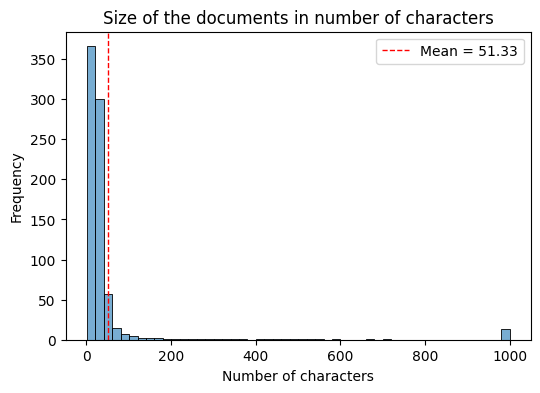


*Vediamo come cambia la distribuzione delle lunghezze considerando le seguenti diverse categorie ['email', 'book_excerpt']


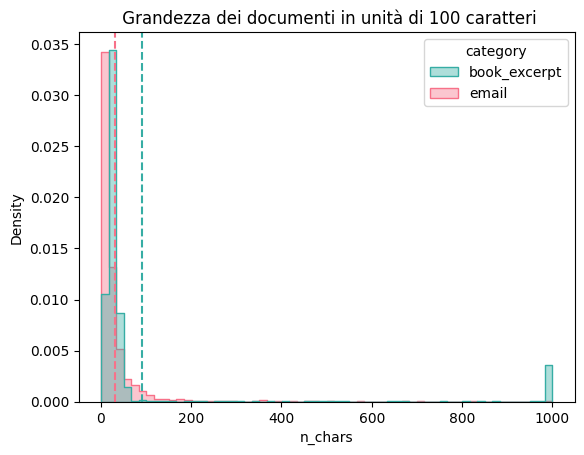

Notiamo che la distribuzione dei frammenti di libri sembra essere, a differenza della distribuzione della lunghezza delle mail, distribuita come la somma di due delta, con molti libri molto poco lunghi e un cluster di estratti di libri di 100000 caratteri. Probabilmente questi sono frammenti di un unico libro più grande, ma evitiamo di indagare ulteriormente.

* Numero di triple per documento: 

The number of triples per document

doc_id
HOUSE_OVERSIGHT_017088_part7    107
HOUSE_OVERSIGHT_027594          107
HOUSE_OVERSIGHT_027460          103
HOUSE_OVERSIGHT_022445           85
HOUSE_OVERSIGHT_017088_part4     79
HOUSE_OVERSIGHT_025452           75
HOUSE_OVERSIGHT_020447_part1     70
HOUSE_OVERSIGHT_027165           69
HOUSE_OVERSIGHT_025707           67
HOUSE_OVERSIGHT_023627           67
dtype: int64

* Numero di triple per explicit_topic: 
explicit_topic
confidentiality and privilege notice       106
biographical death notice                   98
ownership interest documentation   

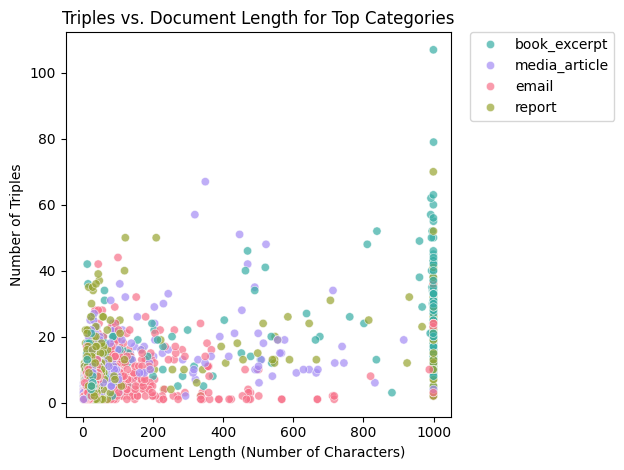

In [8]:
### PRIMA VISUALIZZAZIONE
n_documents = len(documents)
n_triples = len(triples)
print("=== Statistiche Fondamentali (post-pulizia) ===")
print(f"Documenti:          {n_documents}")
print(f"Triple semantiche:  {n_triples}")

#print('\n' + 25*'-' +' Fundamental Quantities' +25*'-'  + '\n')
#print(f'Il numero di documenti è: {n_documents}')
#print(f'Il numero di triple è: {n_triples}\n')

# Documenti per gruppo. Categoria
#print('\n * Il  numero di documenti per categoria \n')
print(documents.groupby('category')['doc_id'].count().sort_values(ascending = False).head(10))

# Numero di documenti per lunghezza
#print('\n * Il numero di documenti per lunghezza (in unità di 100 caratteri):')
#print('Notare che molti documenti sono pagine di documenti più grandi\n')

documents['n_chars'] = documents['full_text'].str.len()/100 # Nuova colonna con la statistica del numero di carateri 

mean_value = documents['n_chars'].mean()
n_bins = 50

plt.figure(figsize=(6,4))
sns.histplot(documents['n_chars'], bins = n_bins, stat = 'frequency', alpha = 0.6)
plt.axvline(mean_value, color='red', linestyle='--', linewidth=1, label=f'Mean = {mean_value:.2f}')
# Labels and title
plt.xlabel('Number of characters')
plt.ylabel('Frequency')
plt.title(f'Size of the documents in number of characters')
plt.legend()
plt.show()

## Tavolazza di colori da usare sempre in  futurp
n_top_categories = 4
top_categories = (
    documents['category']
      .value_counts()
      .head(n_top_categories)
      .index
      .tolist()
) 
colors = sns.color_palette("husl", n_top_categories).as_hex()
category_colors = dict(zip(top_categories, colors))

categorie = ['email', 'book_excerpt']
print(f'\n*Vediamo come cambia la distribuzione delle lunghezze considerando le seguenti diverse categorie {categorie}')

mask = documents['category'].isin(categorie)

doc_plot = documents[mask]
n_bins = 60

sns.histplot(
    data=doc_plot, 
    x='n_chars', 
    hue='category',     # This separates the data by category
    bins=n_bins, 
    palette = category_colors, 
    element="step",     # 'step' or 'poly' makes overlaps easier to see
    stat='density',
    common_norm = False, 
    alpha=0.4,
)

for cat in categorie:
    # Calculate mean for this specific category
    cat_mean = documents[documents['category'] == cat]['n_chars'].mean()
    
    # Get the color from our dictionary
    line_color = category_colors.get(cat)
    
    plt.axvline(
        x=cat_mean, 
        color=line_color, 
        linestyle='--', 
        linewidth=1.5,
        label=f'Mean {cat}' # Optional: this might make the legend very long
    )

plt.title(f" Grandezza dei documenti in unità di 100 caratteri")
plt.show()
print('Notiamo che la distribuzione dei frammenti di libri sembra essere, a differenza della distribuzione della lunghezza delle mail, distribuita come la somma di due delta, con molti libri molto poco lunghi e un cluster di estratti di libri di 100000 caratteri. Probabilmente questi sono frammenti di un unico libro più grande, ma evitiamo di indagare ulteriormente.')

# Numero di triple per documento 
print('\n* Numero di triple per documento: ')
reference_counts = (
    triples.groupby('doc_id')
      .size()
      .rename('n_triples')
      .reset_index()
)
documents = documents.merge( # Nota, se runnato 2 volte il nome della colonna viene cambiato
    reference_counts,
    left_on='doc_id',
    right_on='doc_id',
    how='left'
).fillna(0) # Nuova colonna con il numero di triple per ogni documento
print('\nThe number of triples per document\n')
print(triples.groupby('doc_id').size().sort_values(ascending = False).head(10))

# numero di triple per explicit_topic
print('\n* Numero di triple per explicit_topic: ')
print(triples.groupby('explicit_topic').size().sort_values(ascending = False).head(10))

#numero di triple per explicit_topic
print('\n* Numero di triple per implicit_topic: ')
print(triples.groupby('implicit_topic').size().sort_values(ascending = False).head(10))



doc_plot = documents[documents['category'].isin(top_categories)] 
sns.scatterplot(
    data=doc_plot,
    x='n_chars',
    y='n_triples',
    hue='category',             # 👈 Colors by category
    palette=category_colors,  # 👈 Plug in your existing palette variable here!
    alpha=0.7                   # 👈 Makes dots slightly transparent so you can see overlaps
)

plt.xlabel('Document Length (Number of Characters)')
plt.ylabel('Number of Triples')
plt.title('Triples vs. Document Length for Top Categories')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout() 
plt.show()


------------------------- Bimodalità Densità di Informazione-------------------------

Mostriamo che la densità di informazione ha due comportamenti diversi e non è costante 
    rispetto al numero di caratter di un documento
     
Più precisamente, se consideriamo documenti con un numero di caratteri 
    maggiori di una soglia t, allora la media della densità di informazione decresce.
     
Se da un lato questo è normale, verifichiamo che questa decrescita dell'informazione 
    non è uniforme lung i gruppi e che da origine ad una distribuzione bimodale della densità 
    di informazione nei documenti
     
Ipotizziamo, forti dei grafici, che questo fenomeno è dovuto a un cluster di documenti che sono di categoria "book_excerpt". Non indaghiamo oltre, ma questo diverso comportamento è dovuto al cluster di
    questo tipo di documento, che si vede nello scatter plot, di poca informazione e gran numero di caratteri. Probabilmente sono pezzi di uno stesso libro più grande, che quindi vi

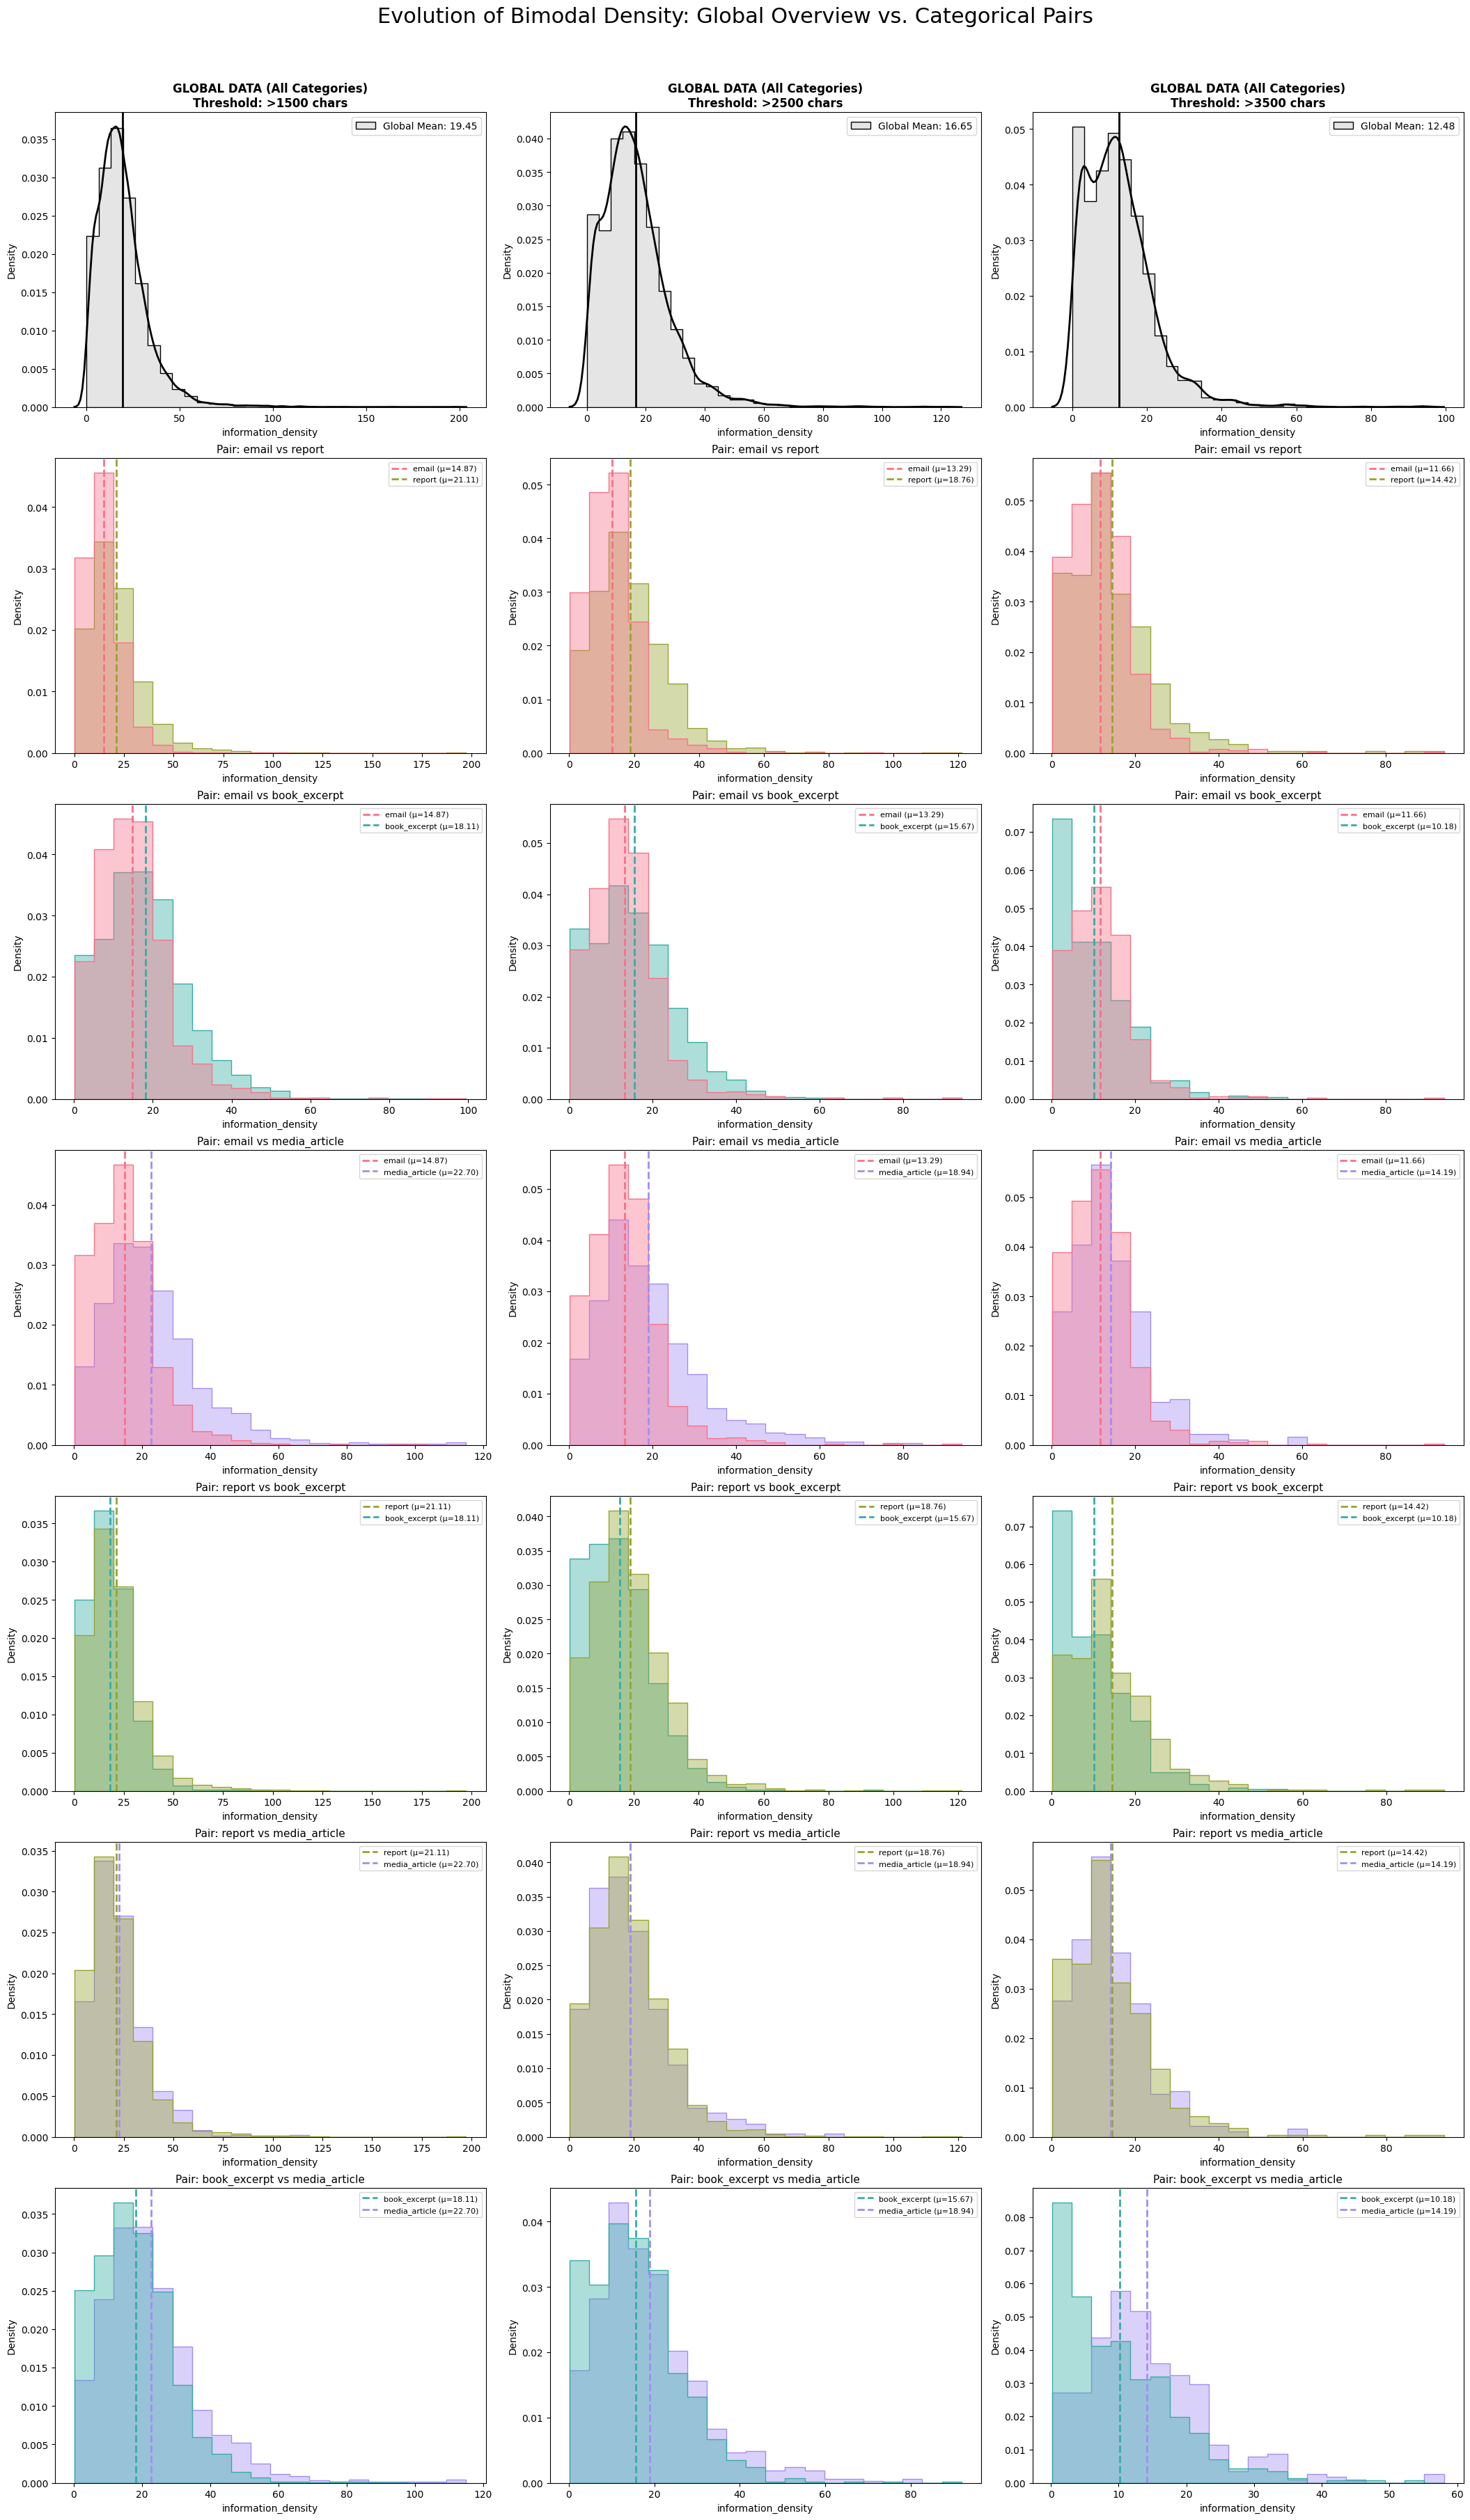

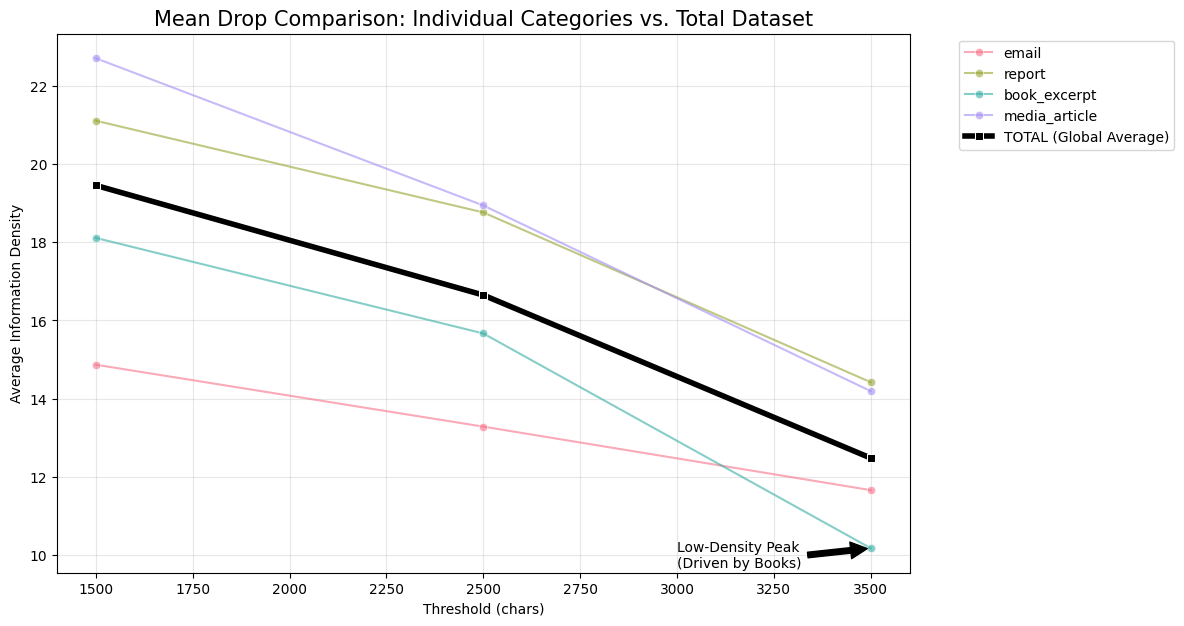

In [9]:
print(25*'-' + ' Bimodalità Densità di Informazione' + 25*'-' + '\n')
print('''Mostriamo che la densità di informazione ha due comportamenti diversi e non è costante 
    rispetto al numero di caratter di un documento
     ''')
print('''Più precisamente, se consideriamo documenti con un numero di caratteri 
    maggiori di una soglia t, allora la media della densità di informazione decresce.
     ''')
print('''Se da un lato questo è normale, verifichiamo che questa decrescita dell\'informazione 
    non è uniforme lung i gruppi e che da origine ad una distribuzione bimodale della densità 
    di informazione nei documenti
     ''')
print('''Ipotizziamo, forti dei grafici, che questo fenomeno è dovuto a un cluster di documenti che sono di categoria "book_excerpt". Non indaghiamo oltre, ma questo diverso comportamento è dovuto al cluster di
    questo tipo di documento, che si vede nello scatter plot, di poca informazione e gran numero di caratteri. Probabilmente sono pezzi di uno stesso libro più grande, che quindi viene pesato troppo nell\'istogramma, ma non indaghiamo oltre.
     ''')
thresholds = [15,25,35] ## n_char è in unità di 1000 caratteri. 
# Andiamo a filtrare i docuumenti con meno di 1000, 2000, e 3000 caratteri 
documents['information_density'] = 100*documents['n_triples']/(documents['n_chars']+1)


# 1. Setup dimensions
coppie_categorie = list(combinations(top_categories, 2))
n_rows_pairs = len(coppie_categorie)
n_rows_total = n_rows_pairs + 1 # +1 for the Global Row at the top
n_cols = len(thresholds)

fig, axes = plt.subplots(n_rows_total, n_cols, figsize=(7 * n_cols, 5 * n_rows_total), constrained_layout=True)

# --- ROW 0: THE GLOBAL DISTRIBUTION (NOT DIVIDED BY CATEGORIES) ---
for col_idx, threshold in enumerate(thresholds):
    ax = axes[0, col_idx]
    
    # Filter Total Data
    all_docs_t = documents[documents['n_chars'] >= threshold]
    global_mean = all_docs_t['information_density'].mean()
    
    # Plotting the undivided distribution
    sns.histplot(
        data=all_docs_t, x='information_density', 
        color='black', element="step", stat="density", 
        bins=30, alpha=0.1, ax=ax, label="Undivided Data"
    )
    # Adding a solid outline to make the bimodal shape clear
    sns.kdeplot(data=all_docs_t, x='information_density', color='black', lw=2, ax=ax)
    
    ax.axvline(global_mean, color='black', linestyle='-', linewidth=2)
    ax.legend([f"Global Mean: {global_mean:.2f}"], loc='upper right')
    ax.set_title(f"GLOBAL DATA (All Categories)\nThreshold: >{threshold*100} chars", fontsize=12, fontweight='bold')

# --- ROWS 1 to N: CATEGORY PAIRS ---
for row_idx, pair in enumerate(coppie_categorie):
    current_row = row_idx + 1 # Offset by 1 for the global row
    
    for col_idx, threshold in enumerate(thresholds):
        ax = axes[current_row, col_idx]

        # Filter Data
        all_docs_t = documents[documents['n_chars'] >= threshold]
        cat_mask = all_docs_t['category'].isin(pair)
        doc_plot = all_docs_t[cat_mask].copy()
        
        # Overlapping Histograms for the pair
        sns.histplot(
            data=doc_plot, x='information_density', hue='category', 
            hue_order=pair, palette=category_colors,
            element="step", multiple="layer", stat="density",     
            common_norm=False, bins=20, alpha=0.4, ax=ax, legend=False
        )

        # Legend with Means and Drops
        legend_elements = []
        for cat in pair:
            cat_data = doc_plot[doc_plot['category'] == cat]
            if not cat_data.empty:
                m = cat_data['information_density'].mean()
                c = category_colors.get(cat)
                ax.axvline(m, color=c, linestyle='--', lw=2)
                legend_elements.append(Line2D([0], [0], color=c, lw=2, linestyle='--', 
                                              label=f'{cat} (μ={m:.2f})'))

        ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
        ax.set_title(f"Pair: {pair[0]} vs {pair[1]}", fontsize=11)

plt.suptitle('Evolution of Bimodal Density: Global Overview vs. Categorical Pairs', fontsize=22, y=1.03)
plt.show()



stats_list = []

for t in thresholds:
    # Filter documents based on current threshold
    mask_t = documents['n_chars'] >= t
    temp_df = documents[mask_t]
    
    for cat in top_categories:
        # Calculate mean for the category at this threshold
        cat_data = temp_df[temp_df['category'] == cat]
        if not cat_data.empty:
            mean_val = cat_data['information_density'].mean()
            stats_list.append({
                'Threshold (chars)': t * 100, # Converting units back to characters
                'Category': cat,
                'Mean Density': mean_val,
                'N': len(cat_data)
            })

# Create a summary DataFrame
df_stats = pd.DataFrame(stats_list)

 # Calculate Global Stats
global_stats = []
for t in thresholds:
    mask_t = documents['n_chars'] >= t
    global_mean = documents[mask_t]['information_density'].mean()
    global_stats.append({
        'Threshold (chars)': t * 100,
        'Category': 'TOTAL (Global)',
        'Mean Density': global_mean
    })

df_global = pd.DataFrame(global_stats)

# Plotting
plt.figure(figsize=(11, 7))

# Plot Categories
sns.lineplot(data=df_stats, x='Threshold (chars)', y='Mean Density', 
             hue='Category', palette=category_colors, marker='o', alpha=0.6)

# Add the TOTAL line
sns.lineplot(data=df_global, x='Threshold (chars)', y='Mean Density', 
             color='black', linewidth=4, linestyle='-', marker='s', 
             label='TOTAL (Global Average)', zorder=10)

# Annotate the Bimodal Insight
if 'book_excerpt' in top_categories:
    book_val = df_stats[df_stats['Category'] == 'book_excerpt']['Mean Density'].iloc[-1]
    plt.annotate('Low-Density Peak\n(Driven by Books)', 
                 xy=(thresholds[-1]*100, book_val), 
                 xytext=(thresholds[-1]*100 - 500, book_val - 0.5),
                 arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)

plt.title('Mean Drop Comparison: Individual Categories vs. Total Dataset', fontsize=15)
plt.ylabel('Average Information Density')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Salvataggio del grafo
Ci dichiariamo soddisfatti della pulizia e dell'indagine preliminare.

#### Grafo Bipartito

Adesso, andiamo a definire il grafo bipartito "Scoppiando" gli edge e facendo dell'attributo doc_id un nodo di tipo diverso. In altre parole, un nodo "entità" è connesso a un documento se e solo se tale nodo entra come attore in una relazione semantica ottenuta dal documento. Un edge che collega un documento a una entità è presente se e solo se una relazione semantica è stata ottenuta da quel documento avente come target tale entità. (Attenzione: I documenti variano sensibilmente e non sono "uniformi", qualsiasi cosa questo voglia dire. Per esempio, alle volte sono pagine di un libro più grande, mentre, altre volte, sono tutto il libro )

Le ragioni per fare questo è che, così facendo, liberiamo gli edge da una variabile in più. Inoltre, da questo grafo bipartito, possiamo ottenere il grafo originale e un grafo duale.


#### Neo4j

Dato che vogliamo che l'analisi sia scalabile, salviamo il nostro grafo nel database Neo4j, appositamente pensato per grandi reti. Il motivo è che calcolare metriche la dentro è più rapido e, soprattutto, non richiede ram. Per mancanza di tempo, non verrà utilizzata (forse per la dashboard) ma carichiamo il dataset nel cloud neao4j lo stesso, per sviluppi futuri. 

#### Grafi 
1. Il grafo delle triple semantiche `g`. E' il grafo in cui i dati sono naturalmente scritti
2. Il grafo delle triple semantiche senza Epstein `g_no_epstein`. Quà, il nodo Epstein è stato rimosso. 
3. Grafo Bipartito Originale (`g_bi`): Multigrafo diretto che mappa 1:1 le relazioni semantiche estratte; ogni arco rappresenta una singola azione parsata tra un Documento e un'Entità.
4. Grafo Bipartito Semplificato (`g_bi_simple`)**: Versione ottimizzata e ripulita dai "super-hub" (es. Epstein), dove gli archi multipli sono collassati in un unico arco pesato, conservando i metadati in liste.
5. Grafo Duale / Proiezione (`g_dual`)**: Rete unipartita di soli Documenti connessi tra loro se condividono entità; il peso dell'arco è il numero di entità comuni. (Anche quà Epstein è stato rimosso). 

In [10]:
#| eval: true
#| echo: true
# Gli insiemi dei nodi 
set_actors = set(triples['actor'].values)
set_targets = set(triples['target'].values)
set_docs = set(triples['doc_id'])

entity_set = set_actors.union(set_targets)
node_set = entity_set.union(set(triples['doc_id'])) #### !!!!Non è detto sia una unione disgiunta!!!!!
nodes = sorted(list(node_set)) 


In [11]:
#| eval: true
#| echo: true
#### Salviamo il grafo bipartito scoppiando le relazioni semantiche usando il doc_od
#### Per via del problema di una granularità non uniforme, forse doc_id non è la miglior variabile
#### statistica 
####
#### Comunque, salviamo in una colonna l'edge iniziale dal quale siamo partiti. Infatti, 
#### per via del fatto che è un multigraph, con molti edge unendo gli stessi nodi, 
#### scopppiando gli edge non si può tornare al grafo iniziale senza sapere a quale edge uscente 
#### corrisponde un edge entrante in un documento. Se 2 relazioni semantiche tra gli stessi attoru
#### e target vengono parsate dallo stesso documento, non possiamo ricostruirla univocamente 
#### (certo, potremmo o unirle a caso o usare la colonna action)


t0 = time.time()
# Creiamo un ID di edge. Quando andiamo a scoppiare gli edge
# Non potremo più recuperare il vecchio grafo, nel caso in cui la stessa relazione è stata 
# Parsata nello stesso documento. 

triples['original_edge_id'] = triples.index.astype(str) 

#  Dizionario per scoppiare il grafo 
rename_entity_to_doc = {'actor': 'source', 'doc_id': 'target'}
rename_doc_to_entity = {'doc_id': 'source', 'target': 'target'}

# Instead of dropping columns blindly, we explicitly select what we want to keep.
# Notice we keep 'action' and 'original_edge_id' for both halves!
colonne = ['actor', 'doc_id', 'action', 'original_edge_id','implicit_topic', 'explicit_topic']
edges_entity_to_doc = triples[colonne].rename(columns=rename_entity_to_doc)
colonne = ['doc_id', 'target', 'action', 'original_edge_id', 'implicit_topic', 'explicit_topic']
edges_doc_to_entity = triples[colonne].rename(columns=rename_doc_to_entity)



# 1. THE VERTICES
# Assuming 'nodes' is your master list/set of all unique entity and document names.
nodes_bipartite = pd.DataFrame({
    'name': nodes  # Column 0: igraph uses the exact text as the lock & key!
})

# Apply your boolean logic
nodes_bipartite['type'] = nodes_bipartite['name'].apply(
    lambda x: False if x in entity_set else True
)
# Turn your documents dataframe into a simple lookup dictionary
# This creates a direct link: {'HOUSE_OVERSIGHT_018721': 'Summary text goes here...'}
summary_lookup = documents.set_index('doc_id')['one_sentence_summary'].to_dict()
# If the node 'name' is in the dictionary (it's a Document), it gets the summary. 
# If it's an Entity, it automatically gets filled with None.
nodes_bipartite['one_sentence_summary'] = nodes_bipartite['name'].map(summary_lookup)

# Create a lookup dictionary from your documents dataframe
url_lookup = documents.set_index('doc_id')['url'].to_dict()
# Map the URLs onto your master node list
nodes_bipartite['url'] = nodes_bipartite['name'].map(url_lookup)

# 2. Gli edge
edges_bipartite = pd.concat([edges_entity_to_doc, edges_doc_to_entity], ignore_index=True)
colonne = ['source', 'target', 'action', 'original_edge_id']
edges_df = edges_bipartite[colonne]
t1 = time.time()
print(f'Dataset preparato in {t1-t0} secondi')


t0 = time.time()


# 3. BUILD THE GRAPH
# igraph will look at the text in 'source'/'target' and match it directly 
# to the text in the 'name' column.
g_bi = ig.Graph.DataFrame(
    edges=edges_df, 
    directed=True, 
    vertices=nodes_bipartite,
    use_vids=False
)

t1 = time.time()
print(f'Bipartite graph saved to memory in {t1 - t0} seconds')
print(g_bi.ecount())
print(len(triples))

Dataset preparato in 0.4407939910888672 secondi
Bipartite graph saved to memory in 0.6673910617828369 seconds
184116
92058


In [12]:

#| eval: false
#| echo: true
### Salviamo il grafo su neo4j

URI = 'neo4j+ssc://2462d63d.databases.neo4j.io'
PASSWORD = 'dhCd2UmxGRQBuW-HKXWKcO4BDnKs0BMcNKSfi6BeWVk'
USER = "neo4j"

node_attributes = ['one_sentence_summary']
edge_attributes = ['action', 'original_edge_id']
with GraphDatabase.driver(URI, auth=(USER, PASSWORD)) as driver:
     utl.save_igraph_to_neo4j(driver, g_bi, node_attrs = node_attributes , edge_attrs = edge_attributes)


Ensuring database constraints and indexes are online...


ServiceUnavailable: Failed to DNS resolve address 2462d63d.databases.neo4j.io:7687: [Errno 8] nodename nor servname provided, or not known

In [ ]:
#| eval: false
#| echo: true
#### Let's try to read the graph

URI = 'neo4j+ssc://2462d63d.databases.neo4j.io'
PASSWORD = 'dhCd2UmxGRQBuW-HKXWKcO4BDnKs0BMcNKSfi6BeWVk'
USER = "neo4j"


with GraphDatabase.driver(URI, auth=(USER, PASSWORD)) as driver:
    g_downloaded = utl.read_neo4j_to_igraph(driver)

In [ ]:
#| eval: false
#| echo: true
## A safety check
node_attributes = ['one_sentence_summary']
edge_attributes = ['action', 'original_edge_id']
utl.compare_graphs(g_downloaded, g_bi, node_attrs = node_attributes, edge_attrs = edge_attributes)
print(g_downloaded.summary())
print(g_bi.summary())

In [13]:
#| eval: true
#| echo: false
# Definiamo i vari grafi 
# L'idea era di fare le dovute proiezioni su neoj4, ma non ho tempo di imparare la sintassi 


colonne = ['actor', 'target', 'doc_id' , 'action', 'url','explicit_topic', 'implicit_topic']
nodi = pd.DataFrame({
    'name': list(entity_set)  # Column 0: igraph uses the exact text as the lock & key!
})

g = ig.Graph.DataFrame(
    edges=triples[colonne], 
    directed=True, 
    vertices=nodi,
    use_vids=False
)

print(f"Clean Graph: {g.vcount()} entities, {g.ecount()} connections.")

## Adesso definiamo la versione semplificata di questo, senza edge multipli 
colonne = ['actor', 'target', 'doc_id' , 'action']
edges_g_simple = triples[colonne].groupby(['actor', 'target']).agg(
    weight=('action', 'size'),
    action_list=('action', lambda x: list(set(x)))
).reset_index()

g_simple = ig.Graph.DataFrame(
    edges = edges_g_simple, 
    directed = True, 
    vertices = nodi, 
    use_vids = False
)
print(f"Clean Graph: {g_simple.vcount()} entities, {g_simple.ecount()} connections.")
print('Rimuovendo i doppioni... Il grafo è praticamente un albero (ha pochi cicli)')


####### Rimuoviamo Epstein da g

t0 = time.time()
g_no_epstein = g.copy()
g_no_epstein.delete_vertices(
    g_no_epstein.vs.select(name="Jeffrey Epstein")
)
t1 = time.time()
print(f'We have deleted Epstein in {t1 - t0} s')


####### Versione con doppioni rimossi del grafo bipartito 
t0 = time.time()

# 1. Raggruppamento e aggregazione con Pandas
colonne = ['source', 'target', 'action', 'original_edge_id']
edges_bipartite_simple = edges_bipartite[colonne].groupby(['source', 'target']).agg(
    weight=('action', 'size'),
    action_list=('action', lambda x: list(set(x))),
    original_edge_id_list=('original_edge_id', lambda x: list(set(x)))
).reset_index()

# 2. Creazione di g_bi_simple
g_bi_simple = ig.Graph.DataFrame(
    edges=edges_bipartite_simple, 
    directed=True, 
    vertices=nodes_bipartite, 
    use_vids=False
)

t1 = time.time()
print(f"Abbiamo collassato gli edge del grafo bipartito via Pandas in {t1 - t0:.2f} secondi.")
print(f"Nodi: {g_bi_simple.vcount()}, Edges: {g_bi_simple.ecount()}")



Clean Graph: 61232 entities, 92058 connections.
Clean Graph: 61232 entities, 67156 connections.
Rimuovendo i doppioni... Il grafo è praticamente un albero (ha pochi cicli)
We have deleted Epstein in 0.07184004783630371 s
Abbiamo collassato gli edge del grafo bipartito via Pandas in 7.78 secondi.
Nodi: 76924, Edges: 130385


In [14]:
#| eval: true
#| echo: false
##### Un possibile grafo duale. Cambia al cambiare dei pesi sugli edge che ci metto

t0 = time.time()

# --- 0. COPIA E EPURAZIONE ---
print("0. Creazione copia di lavoro e rimozione nodi indesiderati...")
# Creiamo una copia esatta per non intaccare il grafo originale
g_bi_working = g_bi_simple.copy()

entita_da_rimuovere = "Jeffrey Epstein"

# Troviamo il nodo ed eliminiamolo DALLA COPIA
nodi_da_eliminare = g_bi_working.vs.select(name=entita_da_rimuovere)
if len(nodi_da_eliminare) > 0:
    g_bi_working.delete_vertices(nodi_da_eliminare)
    print(f"   '{entita_da_rimuovere}' rimosso dalla copia. Nodi restanti: {g_bi_working.vcount()}")
else:
    print(f"   Il nodo non era presente nel grafo.")


# --- 1. ESTRAZIONE METADATI ---
print("\n1. Estrazione metadati da g_bi_working...")

dict_d_to_e = {}
dict_e_to_d = {}
doc_out_ents = {}
doc_in_ents = {}

# Da qui in poi usiamo SOLO g_bi_working
for e in g_bi_working.es:
    source_name = g_bi_working.vs[e.source]['name']
    target_name = g_bi_working.vs[e.target]['name']
    source_is_doc = g_bi_working.vs[e.source]['type']
    
    edge_ids = e['original_edge_id_list'] if 'original_edge_id_list' in e.attributes() else []
    
    if source_is_doc:  
        dict_d_to_e[(source_name, target_name)] = edge_ids
        doc_out_ents.setdefault(source_name, set()).add(target_name)
    else:              
        dict_e_to_d[(source_name, target_name)] = edge_ids
        doc_in_ents.setdefault(target_name, set()).add(source_name)


# --- 2. CALCOLO TOPOLOGIA CON SCIPY ---
print("2. Calcolo della topologia con SciPy...")
edges_idx = g_bi_working.get_edgelist()
sources = [e[0] for e in edges_idx]
targets = [e[1] for e in edges_idx]
weights = np.ones(len(edges_idx)) 

N = g_bi_working.vcount()
M_sparse = sp.csr_matrix((weights, (sources, targets)), shape=(N, N))

types = g_bi_working.vs['type']
ent_idx = [i for i, t in enumerate(types) if t == False]
doc_idx = [i for i, t in enumerate(types) if t == True]

E_to_D = M_sparse[ent_idx, :][:, doc_idx]
D_to_E = M_sparse[doc_idx, :][:, ent_idx]

doc_projection_sparse = D_to_E.dot(E_to_D)
doc_projection_sparse.setdiag(0)
doc_projection_sparse.eliminate_zeros()


# --- 3. IDRATAZIONE EDGE ---
print("3. Augmentiamo degli edge proiettati...")
doc_proj_coo = doc_projection_sparse.tocoo()
doc_names = g_bi_working.vs[doc_idx]['name']

new_edges = []
new_weights = []
new_shared_entities = []
new_original_ids = []

for r, c in zip(doc_proj_coo.row, doc_proj_coo.col):
    doc_u = doc_names[r]
    doc_v = doc_names[c]
    
    ents_u_out = doc_out_ents.get(doc_u, set())
    ents_v_in = doc_in_ents.get(doc_v, set())
    shared = ents_u_out.intersection(ents_v_in)
    
    if not shared:
        continue
        
    edge_ids = []
    for ent in shared:
        edge_ids.extend(dict_d_to_e.get((doc_u, ent), []))
        edge_ids.extend(dict_e_to_d.get((ent, doc_v), []))
        
    new_edges.append((doc_u, doc_v))
    new_weights.append(len(shared)) 
    new_shared_entities.append(list(shared))
    new_original_ids.append(list(set(edge_ids)))


# --- 4. COSTRUZIONE GRAFO DUALE ---
print("4. Costruzione del grafo duale definitivo...")
g_dual_edges = pd.DataFrame({
    'source': [e[0] for e in new_edges],
    'target': [e[1] for e in new_edges],
    'weight': new_weights,
    'shared_entities': new_shared_entities,
    'original_edge_ids': new_original_ids
})

doc_nodes = g_bi_working.vs[doc_idx]
nodes_df = pd.DataFrame({
    'name': doc_nodes['name'],
    'one_sentence_summary': doc_nodes['one_sentence_summary'] if 'one_sentence_summary' in g_bi_working.vertex_attributes() else None,
    'url': doc_nodes['url'] if 'url' in g_bi_working.vertex_attributes() else None
})

g_dual = ig.Graph.DataFrame(
    edges=g_dual_edges,
    directed=True,
    vertices=nodes_df,
    use_vids=False
)

t1 = time.time()
print(f"\nGrafo g_dual finale costruito in {t1 - t0:.2f} secondi.")
print(f"Documenti: {g_dual.vcount()} | Connessioni: {g_dual.ecount()}")

0. Creazione copia di lavoro e rimozione nodi indesiderati...
   'Jeffrey Epstein' rimosso dalla copia. Nodi restanti: 76923

1. Estrazione metadati da g_bi_working...
2. Calcolo della topologia con SciPy...
3. Augmentiamo degli edge proiettati...
4. Costruzione del grafo duale definitivo...

Grafo g_dual finale costruito in 25.98 secondi.
Documenti: 15692 | Connessioni: 1509045


## Statistiche Di Grafo

Adesso andiamo a definire diversi grafi che vogliamo studiare e diamo una descrizione generale delle varie metriche che, dato un grafo, si possono definire. 

#### Grafi

Consideriamo i seguenti grafi: 

- Il grafo bipartito già definito in precedenza
- Il grafo delle relazioni semantiche, dove i nodi sono entità, e cioé  attori o target, e i legami una relazione semantica del tipo *un attore* ha fatto *un'azione* a un *target*. 
- Il grafo bipartito in cui i legami multipli sono stati sostituiti da uno singolo. In pratica, esiste uno e un solo legame tra un entità e un documento se e solo se in tale documento è stata trovata una relazione semantica con attore l'entità. Esiste uno e un solo legame che unisce un documento e un'entità se e solo se esiste una relazione semantica ottenuta dal documento che ha come target l'entità
- Il grafo duale. I nodi sono documenti ed esiste un legame tra due documenti se e solo se esiste una relazione semantica nel primo documento e una nel secondo documento che condividono un'entità, che entra nella prima come target e nella seconda come attore.
- Il grafo delle relazioni semantiche senza Epstein.

#### Metriche 

##### Metriche Globali 
- Numero di nodi
- Numero di archi
- Densità
- Reciprocità (≈ 0 nei grafi bipartiti perfetti)
- Diametro
- Lunghezza media del percorso
- Numero di componenti
- Spectral Gap
##### Metirche di Nodo
- Degree (In / Out / Totale)
- PageRank
- Betweenness
- Eigenvector Centrality
- Hubs → Entità influenti (Nel caso bipartito)
##### Metriche di Edge

#### Pipeline 

Questo documento descrive il flusso completo di un'analisi di grafi che verrà applicato ai nostri casi 

- Creazione del grafo direzionato tramite `igraph` a partire da DataFrame Pandas o un uploas diretto da Neo4j.


- Estrazione della Componente Gigante  
`extract_main_component`
Calcolo delle Weakly Connected Components (WCC).
Motivazione: Evita instabilità nelle metriche globali, rende centralità e clustering interpretabili e Riduce il costo computazionale.


- Statistiche Globali  
`compute_global_statistics`


- Metriche Locali (Nodi e Archi)  
`compute_and_store_metrics`

- Community Detection  
`compute_communities`
Infomap e vettore di Fielder 

**Analisi Spettrale**
- Calcolo del Laplaciano
- Spectral Gap
- Vettore di Fiedler


- Pulizia e Bisezione Spettrale  
`clean_communities_and_bisect`
**Obiettivo:** Rendere le comunità analiticamente utilizzabili.

Filtro Rumore: Comunità Infomap con meno di `X` nodi (es. 50) → assegnate a cluster `-1`.

Bisezione Spettrale: Conversione del Vettore di Fiedler in attributo binario.

```python
# 1. Component Extraction
g = extract_main_component(g, warning_threshold=0.10)

# 2. Add Global Graph Attributes (g["..."])
g = compute_global_statistics(g)

# 3. Add Node & Edge Attributes (g.vs["..."], g.es["..."])
g = compute_and_store_metrics(g)

# 4. Add Community Attributes
g = compute_communities(g)

# 5. Clean and Bisect
g, cleaned_infomap = clean_communities_and_bisect(g, alpha = 0.1)
```

### 📊 Graph Data Dictionary  

Questo documento descrive in modo preciso gli attributi presenti nel grafo g e dei file (`GraphML` e `Parquet`) al termine della pipeline di analisi del grafo bipartito direzionato.

---

#### 1 Attributi a Livello di Grafo  
*(g["..."])*

Descrivono la struttura macroscopica della **Giant Weakly Connected Component (WCC)**.

- **num_vertices (int)**  
  Numero totale di nodi nella componente principale.

- **num_edges (int)**  
  Numero totale di archi nella componente principale.

- **density (float)**  
  Rapporto tra archi osservati e archi teoricamente possibili.

- **reciprocity (float)**  
  Misura della reciprocità degli archi.  
  Per un grafo bipartito perfetto direzionato dovrebbe essere **0.0**.

- **avg_path_length (float)**  
  Lunghezza media dei cammini minimi tra tutte le coppie di nodi connessi.

- **diameter (int)**  
  Lunghezza del cammino minimo più lungo nella rete.

- **spectral_gap (float)**  
  Secondo autovalore della matrice Laplaciana.  
  Misura la robustezza e la connettività globale della rete.

- **louvain_modularity (float)**  
  Valore globale di modularità ottenuto tramite algoritmo Louvain.

- **infomap_modularity (float)**  
  Valore globale ottenuto dall’algoritmo Infomap (basato sul flusso informativo).

---

#### 2 Attributi dei Nodi  
*(g.vs["..."] → nodes.parquet)*

Queste colonne sono presenti nel DataFrame esportato dei nodi.

##### 🔹 Identità e Layout

- **name (string)**  
  Identificativo univoco dell’Entità o Documento.

- **type (boolean)**  
  Classe bipartita:
  - `True / 1` → Documento  
  - `False / 0` → Entità  

- **x, y (float)**  
  Coordinate 2D pre-calcolate per rendering immediato in Streamlit.

##### 🔹 Importanza / Centralità

- **degree_all (int)**  
  Numero totale di connessioni.

- **degree_in (int)**  
  Numero di archi entranti.

- **degree_out (int)**  
  Numero di archi uscenti.

- **pagerank (float)**  
  Misura di influenza basata sul flusso direzionato.

- **betweenness (float)**  
  Frequenza con cui il nodo si trova su cammini minimi (misura di "collo di bottiglia").

- **eigenvector (float)**  
  Influenza basata sulla connessione con nodi a loro volta influenti.

- **hub_score (float)**  
  Score HITS – alto per Entità che puntano a Documenti rilevanti.

- **authority_score (float)**  
  Score HITS – alto per Documenti puntati da Entità influenti.

##### 🔹 Struttura e Comunità

- **coreness (int)**  
  Livello di appartenenza al k-core.

- **clustering_coeff (float)**  
  Coefficiente di clustering locale.

- **fiedler_vector (float)**  
  Coordinata continua derivante dalla decomposizione spettrale.

- **laplacian_split (int)**  
  Versione binarizzata del vettore di Fiedler:
  - `1` se ≥ 0  
  - `0` se < 0  

- **louvain_cluster (int)**  
  ID della comunità assegnata da Louvain.

- **infomap_cluster (int)**  
  ID grezzo assegnato da Infomap.

- **cleaned_infomap (int)**  
  Versione filtrata:  
  comunità troppo piccole vengono assegnate al cluster `-1` (rumore).

---

##### 3. Attributi degli Archi  
*(g.es["..."] → edges.parquet)*

Queste colonne sono presenti nel DataFrame esportato degli archi.

- **source (string)**  
  Nome del nodo origine (Entità).

- **target (string)**  
  Nome del nodo destinazione (Documento).

- **edge_betweenness (float)**  
  Importanza strutturale dell’arco nel connettere parti diverse della rete.

---

#### 4. Esportazione dei Dati

Al termine della pipeline, il grafo viene esportato in due formati:

##### 🔹 Esportazione GraphML (Struttura Completa del Grafo)

```python
g_main.write_graphml("epstein_main_component.graphml")
```

##### Esportazione in formato .parquet

Esportazione di nodi e rispettivi attributi e layout
```python
nodes_df = pd.DataFrame(g_main.vs.attributes())
nodes_df.to_parquet("nodes.parquet", index=False)
```
Esportazione degli archi e dei rispettivi attributi 
```python
edges_df = pd.DataFrame(g_main.es.attributes())
edges_df.to_parquet("edges.parquet", index=False)
```
Esportazione degli Attributi di grafo
```python
graph_stats_df = pd.DataFrame([{
    k: g_main[k] for k in g_main.attributes()
}])

graph_stats_df.to_parquet("graph_stats.parquet", index=False)
```

In [15]:
#| eval: false
#| echo: false
# Wrappo le mie funzioni, che a loro volta wrappano il calcolo di diverse metriche
def compute(g, export_name, warning_threshold_1 = 0.10, warning_threshold_2 = 0.008): 
# Questa funzione mi restringe il grafo alla sua componente connessa massimale
    g = utl.extract_main_component(g, warning_threshold_1 ) 
# Usando funzioni di igraph, mi calcola metriche globali, di nodo e di edges 
    g = utl.compute_global_statistics(g)
    g = utl.compute_and_store_metrics(g)
# Usando funzioni di igraph, mi clusterizza il grafo, ritornando un altro attributo sui vertici
    g = utl.compute_communities(g) 
# Metto il valore dei cluster troppo piccoli a -1
    g = utl.clean_communities_and_bisect(g, warning_threshold_2)
    utl.compute_layout_and_export(g, export_name)
    return g

# Wrappo le funzioni che mi visualizzano le metriche su schermo 
def stampa(g, stringa = '',  n = 10, top_clusters = 5 ): 
    utl.print_global_overview(g, stringa,  top_clusters)
    utl.print_node_standings(g,n)
    utl.print_edge_standings(g,n)

In [16]:
# Let's study g_no_epstein
g_no_epstein = compute(g_no_epstein, export_name = "g_no_epstein")

Analyzing components for graph with 61231 nodes...
  > Largest component: 37796 nodes
  > Second largest component: 37 nodes

--- Computing Global Graph Statistics ---
[Time] Basic counts: 0.00 s
[Time] Density: 0.00 s
[Time] Reciprocity: 0.01 s
Calculating Average Path Length (this may take a minute...)
[Time] Average Path Length: 3.71 s
Calculating Diameter (this may take a minute...)
[Time] Diameter: 3.55 s
✅ Global Statistics computed and stored in 7.3 s total.
Starting metrics computation for graph with 37796 nodes and 59925 edges...

[Time] Degrees (In/Out/All): 0.00 s
[Time] PageRank: 0.02 s
[Time] Node Betweenness: 15.99 s
[Time] Eigenvector Centrality: 0.18 s
Graph is NOT perfectly bipartite. Skipping HITS...
[Time] Coreness (k-core): 0.01 s
[Time] Local Clustering Coefficient: 0.02 s
[Time] Edge Betweenness: 19.87 s

✅ All metrics computed and stored in 36.1 seconds total.

--- Starting Community Detection for 37796 nodes ---


/Users/alessandrogubbiotti/Data-Wrangling-Project/src/my_utils.py:384: RuntimeWarning: Some eigenvector centralities are nearly zero, indicating that the graph may not be (strongly) connected. Eigenvector centrality is not meaningful for disconnected graphs. Location: src/centrality/eigenvector.c:103
  g.vs["eigenvector"] = g.eigenvector_centrality(directed=True)


[Time] Laplacian (Spectral Gap: 0.00631): 208.24 s
[Time] Graph undirected conversion (for Louvain): 0.21 s
[Time] Louvain Community Detection: 0.16 s
[Time] Infomap Community Detection: 9.37 s
✅ Community Detection complete in 218.0 s total.
Cleaning communities (min_size=302.368) and applying bisection...
  > Laplacian Split: 37558 nodes (1) | 238 nodes (0)
  > Infomap: Kept 9 major communities.
  > All other nodes assigned to noise cluster (-1).
--- 1. Computing 2D Layout ---
Graph is not perfectly bipartite. Computing DrL force-directed layout...
[Time] Layout calculated & normalized: 73.57 s

--- 2. Extracting to Pandas DataFrames ---
Nodes DataFrame: (37796, 18)
Edges DataFrame: (59925, 8)

--- 3. Exporting to '../Output/' folder ---

--- 4. Exporting Global Graph Metrics ---
Global metrics exported: ../Output/g_no_epstein_global_metrics.csv
✅ All exports complete! Files saved in ../Output/


In [ ]:
#| eval: false
#| echo: false
g = compute(g,export_name = 'g')

In [ ]:
#| eval: false
#| echo: false
g_simple = compute(g_simple, export_name = 'g_simple')

In [ ]:
#| eval: false
#| echo: false
g_bi_simple = compute(g_bi_simple, export_name = 'g_bi_simple')

In [ ]:
#| eval: false
#| echo: true
g_dual = compute(g_dual, export_name = 'g_dual') #36 minuti solo per il laplaciano

In [ ]:
## Stampo su schermo un po' di metriche
stampa(g_no_epstein, 'Actor -> Target Without Epstein')
#stampa(g, 'Actor -> Action -> Target')
#stampa(g_dual, 'Document -> Document Without Epstein')
#stampa(g_bi_simple, 'Actor -> Document -> Target Bipartite')

In [ ]:
#| eval: false
#| echo: false
### Mi salvo il plot interattivo dei grafi
utl.visualize_top1000_subgraph(g_no_epstein, 'g_no_epstein_top100')
#utl.visualize_top1000_subgraph(g, 'g_top100')
#utl.visualize_top1000_subgraph(g_bi_simple, 'g_bi_simple_top100')
#utl.visualize_top1000_subgraph(g_dual, 'g_dual_top100')

In [ ]:

#| eval: true
#| echo: true

## Chomsky sta in cluster diversi dal principe andrea? 
## La risposta è insoddisfacente perché in questo dataset ci sono poche istanze di Chomsky
## Nei nuovi documenti, invece, appare più spesso. 
good = "Noam Chomsky"
bad = "Prince Andrew, Duke of York"  
#graphs = [g, g_no_epstein, g_simple, g_bi_simple]
graphs = [g_no_epstein]
for grafo in graphs:
    cluster_attr = "cleaned_infomap" if "cleaned_infomap" in grafo.vs.attributes() else "infomap_cluster"
    
    try:
        v1 = grafo.vs.find(name=good).index
        v2 = grafo.vs.find(name=bad).index
    except ValueError as e:
        # Node not found
        missing = good if str(e).find(good) != -1 else bad
        print(f"⚠️ Node '{missing}' not found in this graph, skipping.")
        continue
    
    cluster_v1 = grafo.vs[v1][cluster_attr]
    cluster_v2 = grafo.vs[v2][cluster_attr]

    if cluster_v1 == cluster_v2:
        print(f"✅ '{good}' and '{bad}' are in the same Infomap cluster ({cluster_v1}).")
    else:
        print(f"❌ '{good}' ({cluster_v1}) and '{bad}' ({cluster_v2}) are in different Infomap clusters.")

In [ ]:
#| eval: false
#| echo: false
#triples['implicit_topic'].unique()
#triples['implicit_topic'].count()

In [ ]:
#| eval: true
#| echo: false
# 1. Get your graph data into a DataFrame
df_nodes = g_no_epstein.get_vertex_dataframe()

# 2. Create the cross-tabulation matrix
# Rows will be your Infomap Clusters, Columns will be your Topics
cross_table = pd.crosstab(index=df_nodes['infomap_cluster'], 
                          columns=df_nodes['implicit_topic'])

print(cross_table)

In [ ]:
#| eval: false
#| echo: false
joined_df = pd.merge(triples, documents, on='doc_id', how='left')
print(joined_df.groupby('category')['implicit_topic'].size())

## Debiasing del Grafo {#sec-debiasing}

### Il Problema

Come discusso nella sezione precedente, il grafo è dominato da Jeffrey Epstein 
come nodo hub. Qualsiasi algoritmo di rappresentazione o classificazione 
applicato direttamente su questo grafo produrrà risultati distorti: le metriche 
di centralità saranno dominate dal suo grado, i cluster di Infomap tenderanno 
a formarsi attorno a lui, e gli embedding dei nodi rifletteranno principalmente 
la distanza da Epstein piuttosto che le relazioni tra le altre entità. Questo 
fenomeno è studiato sistematicamente in @jeon2025mitigating e 
@subramonian2024theoretical.

### Strategie Adottate

Adottiamo due strategie complementari.

**Rimozione del nodo Epstein.** La strategia più semplice è rimuovere 
fisicamente il nodo Epstein e tutti gli archi ad esso incidenti, ottenendo il 
grafo $g_{\text{no-Epstein}}$. Questo approccio è brutale ma efficace: le 
relazioni tra le altre entità emergono chiaramente una volta rimosso il nodo 
dominante. Il limite è che si perdono tutte le informazioni sulle interazioni 
dirette con Epstein, che potrebbero essere rilevanti per l'entity resolution.

**Grafo duale pesato.** Una strategia più sofisticata è costruire il grafo 
duale $g_{\text{dual}}$, in cui due documenti sono connessi se condividono 
entità, con peso proporzionale al numero di entità condivise. Questo grafo è 
meno sensibile al bias di grado perché il peso degli archi normalizza 
implicitamente la presenza di Epstein — un documento che cita solo Epstein 
e uno che cita Epstein e altre dieci persone contribuiscono in modo diverso 
alla struttura del grafo duale.

### Confronto

Presentiamo le statistiche di entrambi i grafi nella @sec-graph-stats e 
confrontiamo i risultati di clustering su $g$, $g_{\text{no-Epstein}}$ e 
$g_{\text{dual}}$. L'obiettivo è verificare se la separazione tra Noam Chomsky 
e il Principe Andrea è robusta rispetto alla scelta del grafo — e quindi se 
dipende dalla struttura delle relazioni o è un artefatto del bias di Epstein.

---

## Entity Resolution e Unmasking dei Nodi {#sec-ml}

### Formulazione del Problema

Gli Epstein Files contengono numerosi nodi anonimi — entità identificate 
genericamente come "unknown individual", "individual", o varianti simili. 
L'obiettivo è determinare a quale entità nota corrisponde ciascun nodo anonimo, 
sfruttando la struttura del grafo e gli attributi dei nodi.

Formalmente, dato un nodo anonimo $u$ e l'insieme $V$ dei nodi noti, vogliamo 
definire una funzione di score $s(u, v)$ per ogni $v \in V$ e restituire i 
candidati ordinati per score decrescente. Questo problema è inquadrabile nel 
framework di *masked graph modeling* di @li2023s: un autoencoder su grafo 
apprende rappresentazioni latenti mascherando porzioni della struttura, e usa 
quelle rappresentazioni per ricostruire i nodi mancanti.

### Baseline: Similarità Strutturale di Jaccard

Prima di applicare metodi più complessi, valutiamo una baseline puramente 
strutturale. Per ogni coppia $(u, v)$ calcoliamo la similarità di Jaccard 
sui rispettivi insiemi di vicini $N(u)$ e $N(v)$:

$$J(u, v) = \frac{|N(u) \cap N(v)|}{|N(u) \cup N(v)|}$$

L'intuizione è che due entità che compaiono negli stessi documenti e 
interagiscono con le stesse persone sono probabilmente la stessa entità — 
lo stesso principio usato da @healy_paul_revere_2013 per identificare Paul 
Revere dalla sola analisi dei metadati di rete, senza alcuna informazione 
sul contenuto delle comunicazioni.

I candidati sono ordinati per $J$ decrescente. La baseline è implementata 
direttamente su `igraph` in poche righe e non richiede training.

### Estensione: Random Forest su Feature Strutturali e Testuali

Come estensione della baseline, costruiamo un vettore di feature per ogni 
coppia $(u, v)$ che combina:

- **Feature strutturali**: Jaccard sui vicini, vicini in comune, differenza 
  di grado, differenza di centralità, stesso cluster Infomap
- **Feature testuali**: similarità coseno su `implicit_topic`, similarità 
  coseno su `one_sentence_summary`

Un classificatore Random Forest è addestrato su coppie di nodi noti, 
trattando ogni nodo noto come se fosse anonimo (*leave-one-out*). La variabile 
target è binaria: 1 se la coppia corrisponde alla stessa entità, 0 altrimenti. 
Poiché i match positivi sono rari rispetto ai negativi, utilizziamo 
`class_weight='balanced'`.

### Lavori Futuri: MaskGAE e Graph Transformer

L'estensione naturale è implementare MaskGAE [@li2023s] con Graph Transformer 
[@shehzad2026graph] come encoder. MaskGAE apprende rappresentazioni latenti 
mascherando archi del grafo durante il training, forzando l'encoder a 
ricostruire la struttura mancante — esattamente il tipo di generalizzazione 
necessaria per inferire l'identità di nodi mascherati. Il debiasing preventivo 
[@jeon2025mitigating] rimane un prerequisito necessario: applicare MaskGAE 
su un grafo non debiasato produce embedding che riflettono il bias di grado 
piuttosto che le relazioni semantiche tra le entità.

Una pipeline completa richiederebbe: (1) debiasing del grafo, (2) encoding 
testuale di `one_sentence_summary` tramite sentence-transformer, (3) training 
di MaskGAE con Graph Transformer come encoder, (4) entity resolution tramite 
distanza coseno nello spazio latente.

## Appendici 

### Appendice A: Architettura del Progetto {#sec-architecture}

Per mantenere una pipeline analitica pulita e riproducibile, questo progetto separa rigorosamente i dati grezzi, gli script computazionali e il report finale. La repository è strutturata come segue:

```text
.
├── Bibliography/       # Riferimenti accademici, paper e documentazione citati
├── Data/               # Documenti grezzi e database SQLite elaborati
├── Output/             # Esportazioni della rete (Parquet, GraphML, metriche CSV)
├── Presentation/       # Materiali e slide che riassumono i risultati
│   └── Images/         # Risorse grafiche specifiche per la presentazione
├── Report/             # Jupyter Notebook (report.ipynb) nucleo narrativo dell'analisi
│   ├── report.ipynb    # The source file
│   ├── report.tex      # The file knitted by quarto
│   └── Images/         # Risorse immagine statiche utilizzate nel report finale
├── src/                # Moduli Python (es. my_utils.py) per pulizia dati e algoritmi
├── README.md           # Documentazione principale del progetto
├── clean.sh            # Uno script da applicare al .tex generato da quarto per ottenere il .pdf
├── _quarto.yml         # Il file con i metadata che usa quarto per knittare a .tex
└── requirements.txt    # Tracciamento delle dipendenze Python
```

Vedere @sec-appD per capire come il report.pdf è stato generato a partire da report.ipynb 

---

### Appendice B: Metodologia e Pipeline dei Dati (Utils) {#sec-utils}

Le complesse operazioni di manipolazione dei dati necessarie per trasformare i testi legali grezzi di Epstein in una rete matematica sono state gestite da funzioni di utilità personalizzate situate in `src/my_utils.py`. Di seguito è riportato un riepilogo della logica analitica principale applicata in background al dataset:

**`stampa_info_doc()`**
* **Obiettivo:** Verificare l'accuratezza dell'estrazione dell'IA.
* **Logica:** Prende uno specifico ID documento e formatta in modo ordinato i suoi metadati, il riepilogo e le relazioni semantiche estratte (`Attore -> Azione -> Target`). Questo permette la verifica manuale delle triple rispetto al testo grezzo senza ingombrare il notebook principale.

**`save_igraph_to_neo4j()` & `read_neo4j_to_igraph()`**
* **Obiettivo:** Archiviazione e recupero dal database.
* **Logica:** Traduce in modo sicuro l'oggetto Python `igraph` in memoria in un Graph Database Neo4j (preservando gli attributi dinamici di nodi e archi), e viceversa. Questo garantisce che gli oltre 92.000 archi possano essere archiviati e interrogati in modo persistente.

**`compute_and_store_metrics()`**
* **Obiettivo:** Identificare attori e documenti strutturalmente significativi.
* **Logica:** Calcola una suite completa di metriche di teoria dei grafi (PageRank, Betweenness Centrality, Eigenvector Centrality, HITS Hubs & Authorities e k-coreness). Salva questi punteggi direttamente nei nodi, permettendoci di classificare le entità in base alla loro influenza strutturale piuttosto che al semplice conteggio delle occorrenze.

**`compute_communities()` & `clean_communities_and_bisect()`**
* **Obiettivo:** Rilevare cluster operativi distinti all'interno della rete di Epstein.
* **Logica:** Esegue molteplici algoritmi di rilevamento delle comunità, inclusi **Infomap** (che traccia il flusso della rete orientata) e **Louvain**. Incorpora un meccanismo di pulizia automatizzato che filtra i piccoli cluster di "rumore", assegnando raggruppamenti matematicamente significativi agli attori.

**`compute_layout_and_export()`**
* **Obiettivo:** Preparare la rete per l'analisi visiva ed esterna.
* **Logica:** Calcola le coordinate 2D normalizzate per l'intero grafo. Sceglie dinamicamente un layout Bipartito parallelo se il grafo collega strettamente attori a documenti, o un layout force-directed DrL in caso contrario. Esporta quindi la rete nei formati veloci `Parquet` e `GraphML` nella cartella `Output/`.

**`visualize_top1000_subgraph()`**
* **Obiettivo:** Visualizzazione web interattiva.
* **Logica:** Filtra la rete mantenendo solo i 1.000 nodi più centrali (basati sul PageRank) e genera una rete PyVis HTML interattiva e autonoma, colorata automaticamente in base alle rispettive comunità Infomap.

---
### Appendice C: Esempio di Documento

Vediamo un Epstein File salvato nella variabile documenti.

In [ ]:
#| label: lst-documento
#| lst-cap: "Un esempio di documento"
utl.stampa_info_doc(documents, triples, 'HOUSE_OVERSIGHT_032390', text = True)

In [ ]:
#| label: lst-documento2
#| lst-cap: "Il documento inserito manualmente"
utl.stampa_info_doc(documents, triples, 'HOUSE_OVERSIGHT_013343', text = True) 

### Appendice D: Qualche Modifica da Fare al .tex in Output {#sec-appD}

Il file .pdf generato da quarto presenta delle problematiche riguardanti colori, emoji e, più seriamente, immagini. Decidiamo quindi generare ('knittare') il .tex, effettuare le modifiche su quest'ultimo e compilare. Le modifiche sono le seguenti

Per quanto riguarda le emoji, inseriamo nell'intestazione del file _quarto.yml i seguenti pacchetti latex: ```\usepackage{fontawesome5} \usepackage{newunicodechar}```. Sempre nello stesso header, inseriamo i rimpiazzi per le emoji.

Per quanto riguada i colori, nel processo in cui quarto produce il file .tex i colori presenti presenti nel ```{python}print('')``` non vengono visualizzati.  In particolare, l'output della funzione ```{python} utl.stampa_info_doc``` nel .pdf del report è un po' confuso. Non abbiamo risolto il problema, e l'environment ```{tex} \begin{verbatim}---\end{verbatim}``` del .tex, che contiene il testo degli output dei chuck del notebook, continua a non tenere conto dei colori.

Per quanto riguarda le immagini, bisogna cambiare la grandezza delle immagini manualmente nel file .tex prodotto da quarto. Ho creato lo script ```clean.sh``` che mi esegue le seguenti modifiche suggerite nel file ```Report/report.tex``` : 

- Sostituire`\scriptsize`{=latex}
```{latex}
Molti di questi file sono doppioni. Ecco un esempio \textbar{} DOJ
Released \textbar{} House Released \textbar{}
\textbar:---:\textbar:---:\textbar{} \textbar{}
\pandocbounded{\includegraphics[keepaspectratio,alt={DOJ}]{Images/EFTA01333513_600.jpg}}
\textbar{}
\pandocbounded{\includegraphics[keepaspectratio,alt={House}]{Images/DOJ-OGR-00030902_550.jpg}}
\textbar{}
```
`\normalsize`{=latex}
con
`\scriptsize`{=latex}
```{latex}
Molti di questi file sono doppioni. Ecco un esempio:

\begin{table}[htbp]
\centering
\begin{tabular}{cc}
\textbf{DOJ Released} & \textbf{House Released} \\
\includegraphics[width=0.47\textwidth]{Images/EFTA01333513_600.jpg} & \includegraphics[width=0.43\textwidth]{Images/DOJ-OGR-00030902_550.jpg} \\
\end{tabular}
\caption{Confronto tra i documenti rilasciati dal DOJ e dalla House.}
\label{tab:doppioni}
\end{table}
```
`\normalsize`{=latex}

- Sostituire `\scriptsize`{=latex}
```{latex}
{\def\LTcaptype{none} % do not increment counter
\begin{longtable}[]{@{}
  >{\centering\arraybackslash}p{(\linewidth - 2\tabcolsep) * \real{0.5000}}
  >{\centering\arraybackslash}p{(\linewidth - 2\tabcolsep) * \real{0.5000}}@{}}
\toprule\noalign{}
\begin{minipage}[b]{\linewidth}\centering
DOJ Released
\end{minipage} & \begin{minipage}[b]{\linewidth}\centering
House Released
\end{minipage} \\
\midrule\noalign{}
\endhead
\bottomrule\noalign{}
\endlastfoot
\pandocbounded{\includegraphics[keepaspectratio,alt={DOJ}]{Images/EFTA02346130_600.jpg}}
&
\pandocbounded{\includegraphics[keepaspectratio,alt={House}]{Images/HOUSE_OVERSIGHT_032390_600.jpg}} \\
\end{longtable}
}
```
`\normalsize`{=latex}
con il seguente codice
`\scriptsize`{=latex}
```{latex}
\begin{table}[htbp]
\centering
\begin{tabular}{cc}
\textbf{DOJ Released} & \textbf{House Released} \\
\includegraphics[width=0.45\textwidth]{Images/EFTA02346130_600.jpg} & \includegraphics[width=0.45\textwidth]{Images/HOUSE_OVERSIGHT_032390_600.jpg} \\
\end{tabular}
\caption{Confronto tra i documenti rilasciati dal DOJ e dalla House.}
\label{tab:doppioni}
\end{table}
```
`\normalsize`{=latex}
